In [27]:
# =============================================================================
# BIOCLITE-PUCP: Análisis Exploratorio de Datos (EDA) y Preprocesamiento
# 
# Este notebook realiza:
# 1. Carga y exploración inicial del dataset BIOCLITE_v2.csv
# 2. Análisis estadístico descriptivo de la población
# 3. Visualización de señales crudas y distribución por grupos
# 4. Diseño e implementación de filtros (0.5-20 Hz)
# 5. Segmentación en ventanas con solapamiento
# 6. Extracción de características clásicas (para modelos baseline)
# 7. Preparación de datos para validación cruzada por sujetos
# 
# Autor: Erick Toque
# Basado en: Polvorinos-Fernández et al. (2025) BIOCLITE Dataset
# =============================================================================

## 1. Configuración Inicial

In [61]:
# 1.1 Verificar entorno y librerías
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.signal import butter, filtfilt, freqz
from scipy.stats import skew, kurtosis
from pathlib import Path
import warnings
import random
import json
from datetime import datetime

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [15, 8]
plt.rcParams['font.size'] = 12

# Semillas
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("="*80)
print("VERIFICACIÓN DE ENTORNO")
print("="*80)
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Verificar entorno
NOMBRE_ENTORNO = "BIOCLITE-PUCP"
if NOMBRE_ENTORNO.lower() in sys.executable.lower():
    print(f"\n Entorno virtual correcto: {NOMBRE_ENTORNO}")
else:
    print(f"\n ADVERTENCIA: No estás usando el entorno virtual {NOMBRE_ENTORNO}")

VERIFICACIÓN DE ENTORNO
Python executable: c:\Users\Epepe\anaconda3\envs\BIOCLITE-PUCP\python.exe
Python version: 3.9.13 | packaged by conda-forge | (main, May 27 2022, 16:51:29) [MSC v.1929 64 bit (AMD64)]

 Entorno virtual correcto: BIOCLITE-PUCP


## 2. Configurar Rutas

In [44]:
# 2.1 Definir rutas del proyecto
project_root = Path("D:/BIOCLITE-PUCP")
DATA_PATH = project_root / 'data' / 'BIOCLITE.csv'
OUTPUT_DIR = project_root / 'results' / 'eda'

# Crear directorios
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(project_root / 'results').mkdir(parents=True, exist_ok=True)

print("="*80)
print("RUTAS CONFIGURADAS")
print("="*80)
print(f"Proyecto: {project_root}")
print(f"Datos: {DATA_PATH}")
print(f"Resultados: {OUTPUT_DIR}")
print(f"Archivo existe: {DATA_PATH.exists()}")

RUTAS CONFIGURADAS
Proyecto: D:\BIOCLITE-PUCP
Datos: D:\BIOCLITE-PUCP\data\BIOCLITE.csv
Resultados: D:\BIOCLITE-PUCP\results\eda
Archivo existe: True


## 3. Cargar Dataset

In [45]:
# 3.1 Cargar datos
print("="*80)
print("CARGANDO DATASET")
print("="*80)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Archivo no encontrado: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f" Dataset cargado exitosamente")
print(f"   • Filas: {df.shape[0]:,}")
print(f"   • Columnas: {df.shape[1]}")
print(f"   • Memoria: {df.memory_usage().sum() / 1024**2:.2f} MB")

# Mostrar información básica
print("\n Primeras 2 filas:")
print(df.head(2))
print("\n Columnas:")
print(df.columns.tolist())
print("\n Tipos de datos:")
print(df.dtypes.value_counts())
print(f"\n Valores nulos: {df.isnull().sum().sum()}")
print(f" Filas duplicadas: {df.duplicated().sum()}")

CARGANDO DATASET
 Dataset cargado exitosamente
   • Filas: 2,287,709
   • Columnas: 14
   • Memoria: 244.35 MB

 Primeras 2 filas:
   Sesion  Grupo_sesion  Participante_sesion  Dia_sesion  Contexto_sesion  \
0       1             1                    1           1                1   
1       1             1                    1           1                1   

   Ejercicio  UPDRS  Tiempo_ms    Acc_X     Acc_Y     Acc_Z    Gyro_X  \
0          1      0    1409964 -3.74932 -5.058948  7.692570  0.013439   
1          1      0    1409984 -3.82354 -5.046977  7.606379  0.012217   

     Gyro_Y    Gyro_Z  
0  0.015882 -0.002443  
1  0.015882  0.001222  

 Columnas:
['Sesion', 'Grupo_sesion', 'Participante_sesion', 'Dia_sesion', 'Contexto_sesion', 'Ejercicio', 'UPDRS', 'Tiempo_ms', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z']

 Tipos de datos:
int64      8
float64    6
Name: count, dtype: int64

 Valores nulos: 0
 Filas duplicadas: 922


In [16]:
print("="*80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*80)

# Información básica
print("\n Información de columnas:")
print(df.info())

print("\n Tipos de datos:")
print(df.dtypes.value_counts())

print("\n Estadísticas descriptivas:")
print(df.describe())

print("\n Valores nulos:")
print(df.isnull().sum())

print("\n Filas duplicadas:")
print(f"Total: {df.duplicated().sum()}")

INFORMACIÓN GENERAL DEL DATASET

 Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2287709 entries, 0 to 2287708
Data columns (total 14 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Sesion               int64  
 1   Grupo_sesion         int64  
 2   Participante_sesion  int64  
 3   Dia_sesion           int64  
 4   Contexto_sesion      int64  
 5   Ejercicio            int64  
 6   UPDRS                int64  
 7   Tiempo_ms            int64  
 8   Acc_X                float64
 9   Acc_Y                float64
 10  Acc_Z                float64
 11  Gyro_X               float64
 12  Gyro_Y               float64
 13  Gyro_Z               float64
dtypes: float64(6), int64(8)
memory usage: 244.4 MB
None

 Tipos de datos:
int64      8
float64    6
Name: count, dtype: int64

 Estadísticas descriptivas:
             Sesion  Grupo_sesion  Participante_sesion    Dia_sesion  \
count  2.287709e+06  2.287709e+06         2.287709e+06  

## 4. Crear Identificador Único de Sujeto

CREACIÓN DE IDENTIFICADOR ÚNICO DE SUJETO

 Total sujetos únicos: 40
   • Controles: 16
   • Parkinson: 24

ANÁLISIS DE SESIONES POR GRUPO

 ESTADÍSTICAS GLOBALES (todos los sujetos):
   • Media: 8.15 sesiones
   • Desviación estándar: 1.67
   • Mínimo: 2
   • Máximo: 9
   • Mediana: 9
   • Total sesiones (suma): 326

 GRUPO CONTROL (n=16 sujetos):
   • Media: 8.50 sesiones
   • Desviación estándar: 1.32
   • Mínimo: 4
   • Máximo: 9
   • Mediana: 9
   • Total sesiones (suma): 136

 GRUPO PARKINSON (n=24 sujetos):
   • Media: 7.92 sesiones
   • Desviación estándar: 1.86
   • Mínimo: 2
   • Máximo: 9
   • Mediana: 9
   • Total sesiones (suma): 190


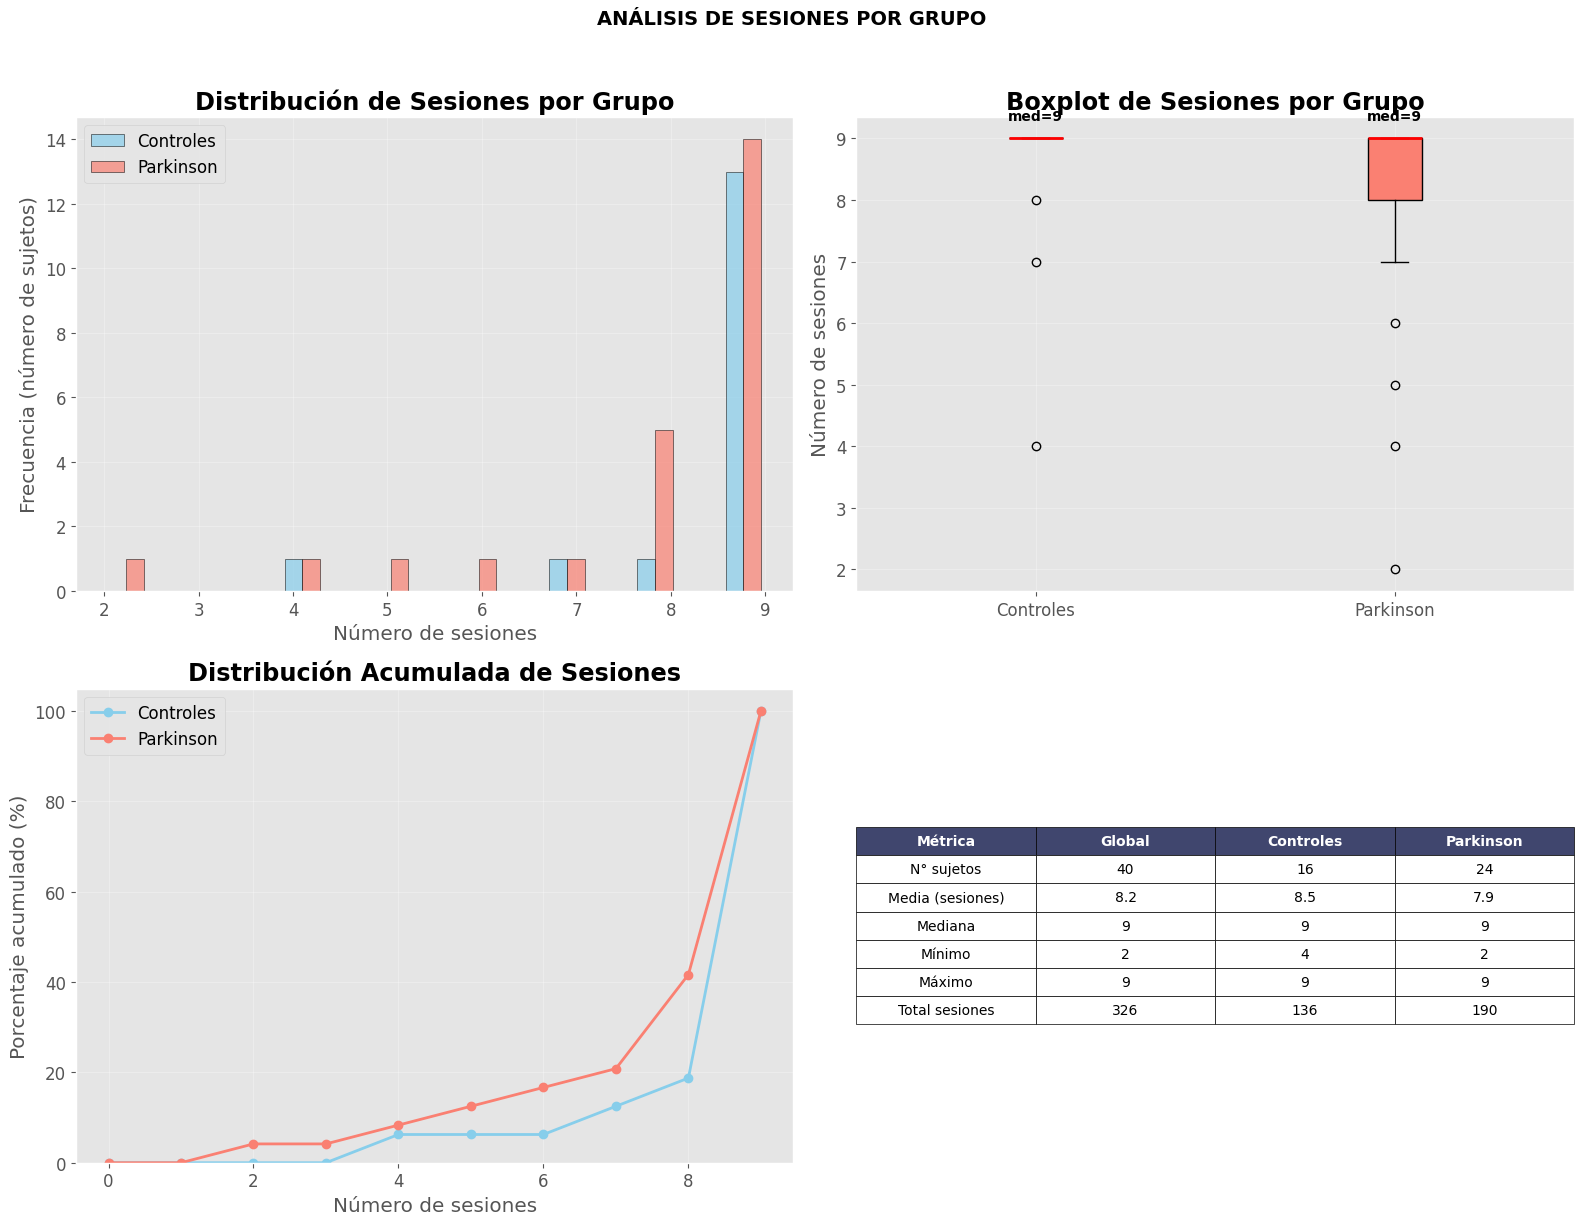


DISTRIBUCIÓN DETALLADA DE SESIONES

📋 **DISTRIBUCIÓN DE SESIONES POR SUJETO:**
 N° Sesiones  Controles (n)  Controles (%)  Parkinson (n)  Parkinson (%)  Total (n)  Total (%)
           2              0            0.0              1            4.2          1        2.5
           4              1            6.2              1            4.2          2        5.0
           5              0            0.0              1            4.2          1        2.5
           6              0            0.0              1            4.2          1        2.5
           7              1            6.2              1            4.2          2        5.0
           8              1            6.2              5           20.8          6       15.0
           9             13           81.2             14           58.3         27       67.5

✅ Tabla guardada en: D:\BIOCLITE-PUCP\results\eda/distribucion_sesiones.csv


In [69]:
# 4.1 Crear SubjectID y analizar sesiones por grupo
print("="*80)
print("CREACIÓN DE IDENTIFICADOR ÚNICO DE SUJETO")
print("="*80)

df['SubjectID'] = df['Grupo_sesion'].astype(str) + '_' + df['Participante_sesion'].astype(str)

# Verificar sujetos totales
n_sujetos = df['SubjectID'].nunique()
n_controles = df[df['Grupo_sesion'] == 0]['SubjectID'].nunique()
n_parkinson = df[df['Grupo_sesion'] == 1]['SubjectID'].nunique()

print(f"\n Total sujetos únicos: {n_sujetos}")
print(f"   • Controles: {n_controles}")
print(f"   • Parkinson: {n_parkinson}")

# ============================================
# ANÁLISIS DE SESIONES POR GRUPO
# ============================================
print("\n" + "="*80)
print("ANÁLISIS DE SESIONES POR GRUPO")
print("="*80)

# Calcular sesiones por sujeto para cada grupo
sesiones_control = df[df['Grupo_sesion'] == 0].groupby('SubjectID')['Sesion'].nunique()
sesiones_parkinson = df[df['Grupo_sesion'] == 1].groupby('SubjectID')['Sesion'].nunique()
sesiones_total = df.groupby('SubjectID')['Sesion'].nunique()

print(f"\n ESTADÍSTICAS GLOBALES (todos los sujetos):")
print(f"   • Media: {sesiones_total.mean():.2f} sesiones")
print(f"   • Desviación estándar: {sesiones_total.std():.2f}")
print(f"   • Mínimo: {sesiones_total.min()}")
print(f"   • Máximo: {sesiones_total.max()}")
print(f"   • Mediana: {sesiones_total.median():.0f}")
print(f"   • Total sesiones (suma): {sesiones_total.sum():.0f}")

print(f"\n GRUPO CONTROL (n={n_controles} sujetos):")
print(f"   • Media: {sesiones_control.mean():.2f} sesiones")
print(f"   • Desviación estándar: {sesiones_control.std():.2f}")
print(f"   • Mínimo: {sesiones_control.min()}")
print(f"   • Máximo: {sesiones_control.max()}")
print(f"   • Mediana: {sesiones_control.median():.0f}")
print(f"   • Total sesiones (suma): {sesiones_control.sum():.0f}")

print(f"\n GRUPO PARKINSON (n={n_parkinson} sujetos):")
print(f"   • Media: {sesiones_parkinson.mean():.2f} sesiones")
print(f"   • Desviación estándar: {sesiones_parkinson.std():.2f}")
print(f"   • Mínimo: {sesiones_parkinson.min()}")
print(f"   • Máximo: {sesiones_parkinson.max()}")
print(f"   • Mediana: {sesiones_parkinson.median():.0f}")
print(f"   • Total sesiones (suma): {sesiones_parkinson.sum():.0f}")

# ============================================
# VISUALIZACIÓN COMPARATIVA
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histograma comparativo
ax = axes[0, 0]
ax.hist([sesiones_control, sesiones_parkinson], bins=15, 
        label=['Controles', 'Parkinson'],
        color=['skyblue', 'salmon'], edgecolor='black', alpha=0.7)
ax.set_xlabel('Número de sesiones')
ax.set_ylabel('Frecuencia (número de sujetos)')
ax.set_title('Distribución de Sesiones por Grupo', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Boxplot comparativo
ax = axes[0, 1]
bp = ax.boxplot([sesiones_control, sesiones_parkinson], 
                labels=['Controles', 'Parkinson'],
                patch_artist=True,
                boxprops=dict(facecolor='skyblue'),
                medianprops=dict(color='red', linewidth=2))
bp['boxes'][1].set_facecolor('salmon')
ax.set_ylabel('Número de sesiones')
ax.set_title('Boxplot de Sesiones por Grupo', fontweight='bold')
ax.grid(True, alpha=0.3)

# Añadir valores de mediana
for i, data in enumerate([sesiones_control, sesiones_parkinson]):
    ax.text(i+1, data.median() + 0.3, f'med={data.median():.0f}', 
            ha='center', fontsize=10, fontweight='bold')

# 3. Distribución acumulada
ax = axes[1, 0]
# Calcular frecuencias acumuladas
bins = range(0, 11)
hist_control, _ = np.histogram(sesiones_control, bins=bins)
hist_parkinson, _ = np.histogram(sesiones_parkinson, bins=bins)
cum_control = np.cumsum(hist_control) / len(sesiones_control) * 100
cum_parkinson = np.cumsum(hist_parkinson) / len(sesiones_parkinson) * 100

ax.plot(bins[:-1], cum_control, 'o-', color='skyblue', linewidth=2, label='Controles')
ax.plot(bins[:-1], cum_parkinson, 'o-', color='salmon', linewidth=2, label='Parkinson')
ax.set_xlabel('Número de sesiones')
ax.set_ylabel('Porcentaje acumulado (%)')
ax.set_title('Distribución Acumulada de Sesiones', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

# 4. Tabla resumen
ax = axes[1, 1]
ax.axis('off')
ax.axis('tight')

# Crear tabla comparativa
tabla_data = [
    ['Métrica', 'Global', 'Controles', 'Parkinson'],
    ['N° sujetos', f'{n_sujetos}', f'{n_controles}', f'{n_parkinson}'],
    ['Media (sesiones)', f'{sesiones_total.mean():.1f}', f'{sesiones_control.mean():.1f}', f'{sesiones_parkinson.mean():.1f}'],
    ['Mediana', f'{sesiones_total.median():.0f}', f'{sesiones_control.median():.0f}', f'{sesiones_parkinson.median():.0f}'],
    ['Mínimo', f'{sesiones_total.min()}', f'{sesiones_control.min()}', f'{sesiones_parkinson.min()}'],
    ['Máximo', f'{sesiones_total.max()}', f'{sesiones_control.max()}', f'{sesiones_parkinson.max()}'],
    ['Total sesiones', f'{sesiones_total.sum():.0f}', f'{sesiones_control.sum():.0f}', f'{sesiones_parkinson.sum():.0f}']
]

tabla = ax.table(cellText=tabla_data, loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.5)

# Colorear encabezados
for j in range(4):
    tabla[(0, j)].set_facecolor('#40466e')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

plt.suptitle('ANÁLISIS DE SESIONES POR GRUPO', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sesiones_por_grupo_detallado.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# DISTRIBUCIÓN DETALLADA (tabla de frecuencias)
# ============================================
print("\n" + "="*80)
print("DISTRIBUCIÓN DETALLADA DE SESIONES")
print("="*80)

# Crear DataFrame con la distribución
distribucion = pd.DataFrame({
    'N° Sesiones': range(1, 11),
    'Controles (n)': [sum(sesiones_control == i) for i in range(1, 11)],
    'Controles (%)': [sum(sesiones_control == i)/len(sesiones_control)*100 if len(sesiones_control) > 0 else 0 for i in range(1, 11)],
    'Parkinson (n)': [sum(sesiones_parkinson == i) for i in range(1, 11)],
    'Parkinson (%)': [sum(sesiones_parkinson == i)/len(sesiones_parkinson)*100 if len(sesiones_parkinson) > 0 else 0 for i in range(1, 11)],
    'Total (n)': [sum(sesiones_total == i) for i in range(1, 11)],
    'Total (%)': [sum(sesiones_total == i)/len(sesiones_total)*100 for i in range(1, 11)]
})

# Filtrar solo filas con datos
distribucion = distribucion[distribucion['Total (n)'] > 0]
print("\n📋 **DISTRIBUCIÓN DE SESIONES POR SUJETO:**")
print(distribucion.round(1).to_string(index=False))

# Guardar tabla
distribucion.to_csv(OUTPUT_DIR / 'distribucion_sesiones.csv', index=False)
print(f"\n✅ Tabla guardada en: {OUTPUT_DIR}/distribucion_sesiones.csv")

## 7. Análisis de Población

ANÁLISIS DE POBLACIÓN

 FRECUENCIAS ABSOLUTAS:
   • Muestras: Controles=954,464, Parkinson=1,333,245
   • Sujetos: Controles=16, Parkinson=24

 FRECUENCIAS RELATIVAS (porcentajes):
   • Muestras:
     - Controles: 41.7% (954,464)
     - Parkinson: 58.3% (1,333,245)
   • Sujetos:
     - Controles: 40.0% (16)
     - Parkinson: 60.0% (24)

 TOTALES:
   • Muestras: 2,287,709
   • Sujetos: 40


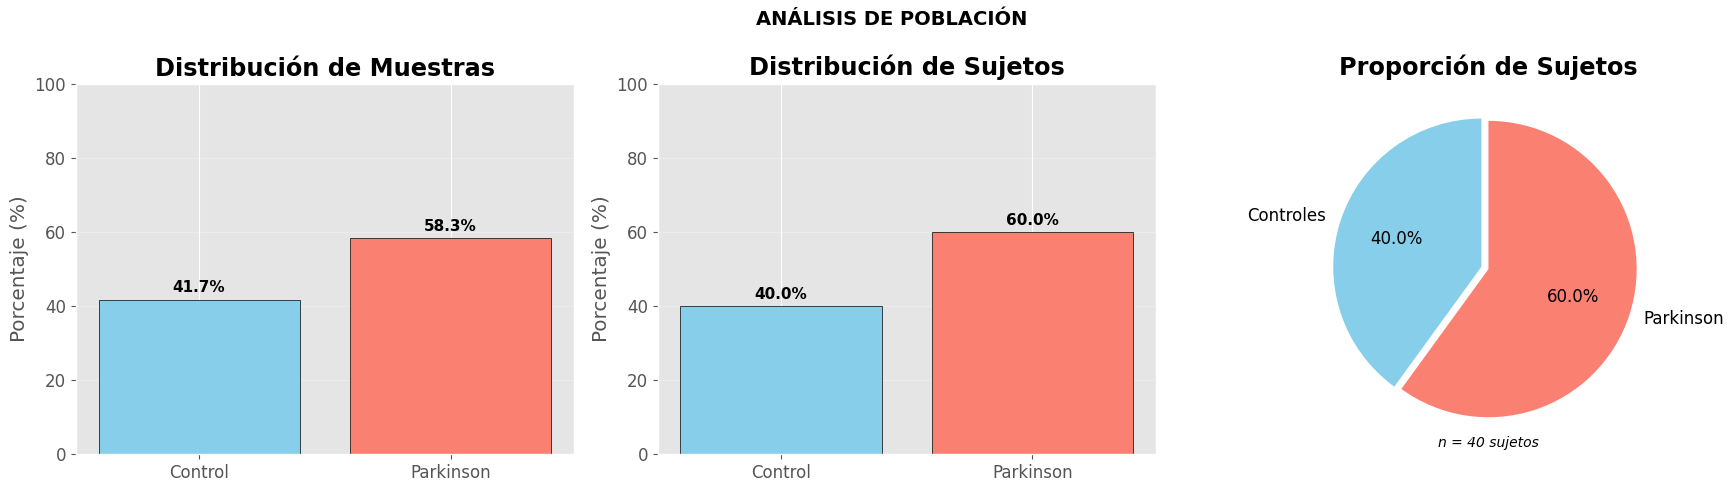

In [67]:
# 5.1 Distribución por grupos (con porcentajes SOLO en gráficos)
print("="*80)
print("ANÁLISIS DE POBLACIÓN")
print("="*80)

# Calcular frecuencias absolutas y relativas
grupo_counts = df['Grupo_sesion'].value_counts()
sujetos_por_grupo = df.groupby('Grupo_sesion')['SubjectID'].nunique()

total_muestras = len(df)
total_sujetos = df['SubjectID'].nunique()

print(f"\n FRECUENCIAS ABSOLUTAS:")
print(f"   • Muestras: Controles={grupo_counts[0]:,}, Parkinson={grupo_counts[1]:,}")
print(f"   • Sujetos: Controles={sujetos_por_grupo[0]}, Parkinson={sujetos_por_grupo[1]}")

print(f"\n FRECUENCIAS RELATIVAS (porcentajes):")
print(f"   • Muestras:")
print(f"     - Controles: {grupo_counts[0]/total_muestras*100:.1f}% ({grupo_counts[0]:,})")
print(f"     - Parkinson: {grupo_counts[1]/total_muestras*100:.1f}% ({grupo_counts[1]:,})")
print(f"   • Sujetos:")
print(f"     - Controles: {sujetos_por_grupo[0]/total_sujetos*100:.1f}% ({sujetos_por_grupo[0]})")
print(f"     - Parkinson: {sujetos_por_grupo[1]/total_sujetos*100:.1f}% ({sujetos_por_grupo[1]})")

print(f"\n TOTALES:")
print(f"   • Muestras: {total_muestras:,}")
print(f"   • Sujetos: {total_sujetos}")

# Visualización - SOLO PORCENTAJES EN GRÁFICOS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Muestras (solo porcentajes)
ax = axes[0]
porcentajes_muestras = [grupo_counts[0]/total_muestras*100, grupo_counts[1]/total_muestras*100]
bars = ax.bar(['Control', 'Parkinson'], porcentajes_muestras,
              color=['skyblue', 'salmon'], edgecolor='black')
ax.set_title(f'Distribución de Muestras', fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Añadir SOLO porcentajes en las barras
for bar, pct in zip(bars, porcentajes_muestras):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Gráfico 2: Sujetos (solo porcentajes)
ax = axes[1]
porcentajes_sujetos = [sujetos_por_grupo[0]/total_sujetos*100, sujetos_por_grupo[1]/total_sujetos*100]
bars = ax.bar(['Control', 'Parkinson'], porcentajes_sujetos,
              color=['skyblue', 'salmon'], edgecolor='black')
ax.set_title(f'Distribución de Sujetos', fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Añadir SOLO porcentajes en las barras
for bar, pct in zip(bars, porcentajes_sujetos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Gráfico 3: Proporción (ya es porcentual)
ax = axes[2]
wedges, texts, autotexts = ax.pie(porcentajes_sujetos,
                                   labels=['Controles', 'Parkinson'],
                                   autopct='%1.1f%%',
                                   colors=['skyblue', 'salmon'],
                                   startangle=90,
                                   explode=(0.05, 0))
ax.set_title('Proporción de Sujetos', fontweight='bold')

# Añadir etiqueta con total (solo para info, no en gráfico principal)
ax.text(0, -1.2, f'n = {total_sujetos} sujetos', 
        ha='center', fontsize=10, style='italic')

plt.suptitle('ANÁLISIS DE POBLACIÓN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribucion_poblacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis de Ejercicios

ANÁLISIS DE EJERCICIOS

📊 Distribución por ejercicio:
           Control  Parkinson
Ejercicio                    
1           202395     282270
2           190509     272084
3            77909     104704
4            39533      58628
5           132896     183899
6           131801     184800
7            33052      43615
8           146369     203245


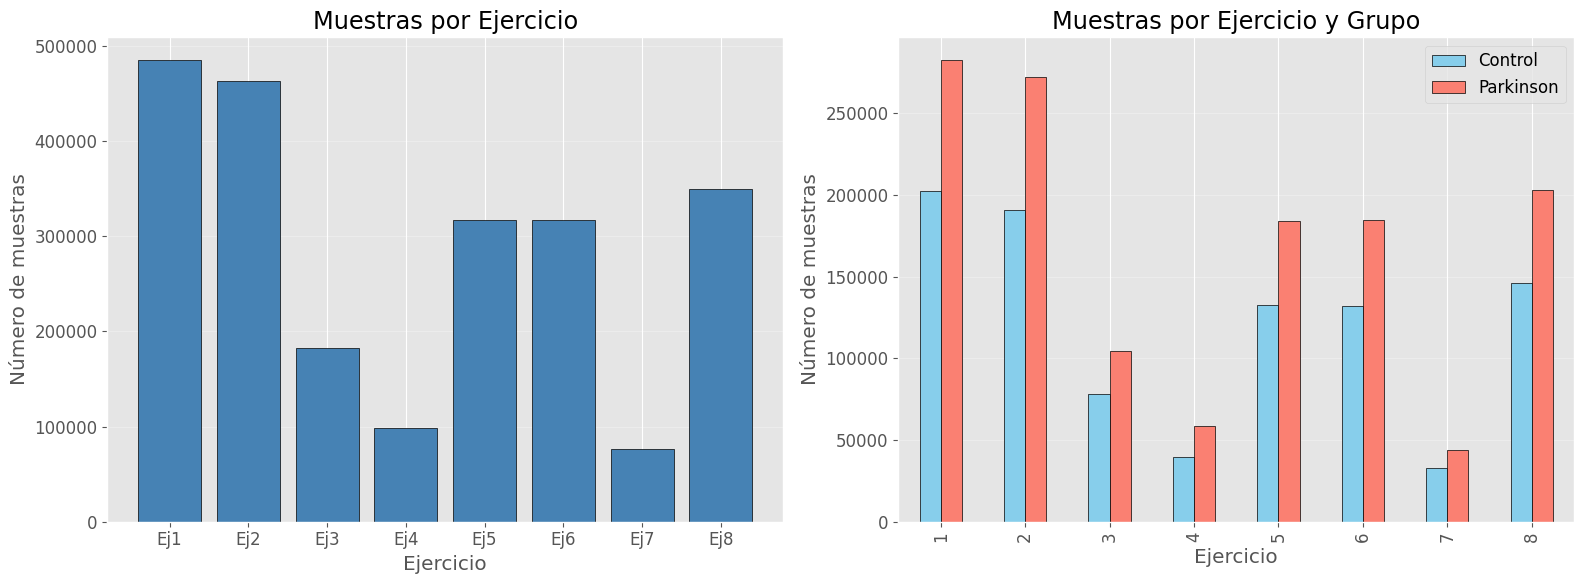

In [48]:
# 6.1 Configurar mapeos
print("="*80)
print("ANÁLISIS DE EJERCICIOS")
print("="*80)

ejercicios_nombres = {
    1: 'Temblor reposo (MDS-UPDRS 3.17)',
    2: 'Temblor postural (MDS-UPDRS 3.15)',
    3: 'Brazos al pecho (propio)',
    4: 'Tapping dedos (MDS-UPDRS 3.4)',
    5: 'Abrir/cerrar mano (MDS-UPDRS 3.5)',
    6: 'Pronación/supinación (MDS-UPDRS 3.6)',
    7: 'Levantarse silla (MDS-UPDRS 3.9)',
    8: 'Marcha (MDS-UPDRS 3.10)'
}

# Distribución
ejercicio_counts = df['Ejercicio'].value_counts().sort_index()
ejercicio_grupo = df.groupby(['Ejercicio', 'Grupo_sesion']).size().unstack()
ejercicio_grupo.columns = ['Control', 'Parkinson']

print("\n📊 Distribución por ejercicio:")
print(ejercicio_grupo)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# General
ax = axes[0]
bars = ax.bar([f'Ej{e}' for e in ejercicio_counts.index], ejercicio_counts.values,
              color='steelblue', edgecolor='black')
ax.set_title('Muestras por Ejercicio')
ax.set_xlabel('Ejercicio')
ax.set_ylabel('Número de muestras')
ax.grid(axis='y', alpha=0.3)

# Por grupo
ax = axes[1]
ejercicio_grupo.plot(kind='bar', ax=ax, color=['skyblue', 'salmon'], edgecolor='black')
ax.set_title('Muestras por Ejercicio y Grupo')
ax.set_xlabel('Ejercicio')
ax.set_ylabel('Número de muestras')
ax.legend(['Control', 'Parkinson'])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribucion_ejercicios.png', dpi=150)
plt.show()

## 9. Análisis de Contexto

ANÁLISIS DE CONTEXTO

📊 Distribución por contexto:
                 Control  Parkinson
Contexto_sesion                    
0                 735541    1024220
1                 113711     142208
2                 105212     166817


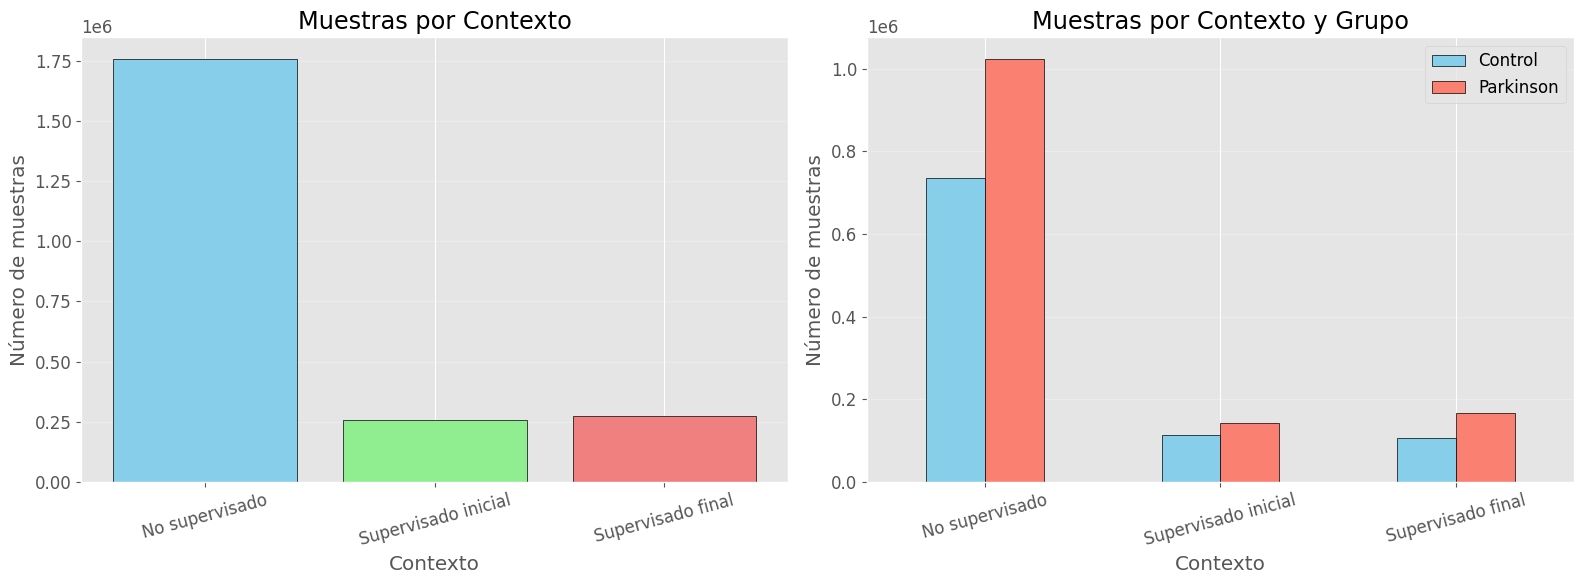

In [49]:
# 7.1 Configurar contextos
print("="*80)
print("ANÁLISIS DE CONTEXTO")
print("="*80)

contexto_nombres = {
    0: 'No supervisado',
    1: 'Supervisado inicial',
    2: 'Supervisado final'
}

# Distribución
contexto_counts = df['Contexto_sesion'].value_counts().sort_index()
contexto_grupo = df.groupby(['Contexto_sesion', 'Grupo_sesion']).size().unstack()
contexto_grupo.columns = ['Control', 'Parkinson']

print("\n📊 Distribución por contexto:")
print(contexto_grupo)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# General
ax = axes[0]
bars = ax.bar([contexto_nombres[i] for i in contexto_counts.index],
              contexto_counts.values,
              color=['skyblue', 'lightgreen', 'lightcoral'],
              edgecolor='black')
ax.set_title('Muestras por Contexto')
ax.set_xlabel('Contexto')
ax.set_ylabel('Número de muestras')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

# Por grupo
ax = axes[1]
contexto_grupo.plot(kind='bar', ax=ax, color=['skyblue', 'salmon'], edgecolor='black')
ax.set_title('Muestras por Contexto y Grupo')
ax.set_xlabel('Contexto')
ax.set_ylabel('Número de muestras')
ax.set_xticklabels([contexto_nombres[i] for i in contexto_grupo.index], rotation=15)
ax.legend(['Control', 'Parkinson'])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribucion_contexto.png', dpi=150)
plt.show()

## 10. Análisis de UPDRS

ANÁLISIS DE UPDRS POR CONTEXTO

📊 **TOTAL MUESTRAS CON UPDRS VÁLIDO:** 284,648
   • Esto representa 12.4% del dataset total

DISTRIBUCIÓN GLOBAL (todos los contextos)

📊 **FRECUENCIAS ABSOLUTAS:**
   UPDRS 0: 68,902 muestras
   UPDRS 1: 124,706 muestras
   UPDRS 2: 77,240 muestras
   UPDRS 3: 12,803 muestras
   UPDRS 4: 997 muestras

📊 **FRECUENCIAS RELATIVAS:**
   UPDRS 0: 24.2%
   UPDRS 1: 43.8%
   UPDRS 2: 27.1%
   UPDRS 3: 4.5%
   UPDRS 4: 0.4%

DISTRIBUCIÓN POR CONTEXTO

📊 **Supervisado inicial (Clínica)** (n=131,091 muestras - 46.1% del total)
   UPDRS 0: 33,022 (25.2%)
   UPDRS 1: 56,423 (43.0%)
   UPDRS 2: 34,124 (26.0%)
   UPDRS 3: 7,522 (5.7%)
   UPDRS 4: 0 (0.0%)

📊 **Supervisado final (Clínica)** (n=153,557 muestras - 53.9% del total)
   UPDRS 0: 35,880 (23.4%)
   UPDRS 1: 68,283 (44.5%)
   UPDRS 2: 43,116 (28.1%)
   UPDRS 3: 5,281 (3.4%)
   UPDRS 4: 997 (0.6%)


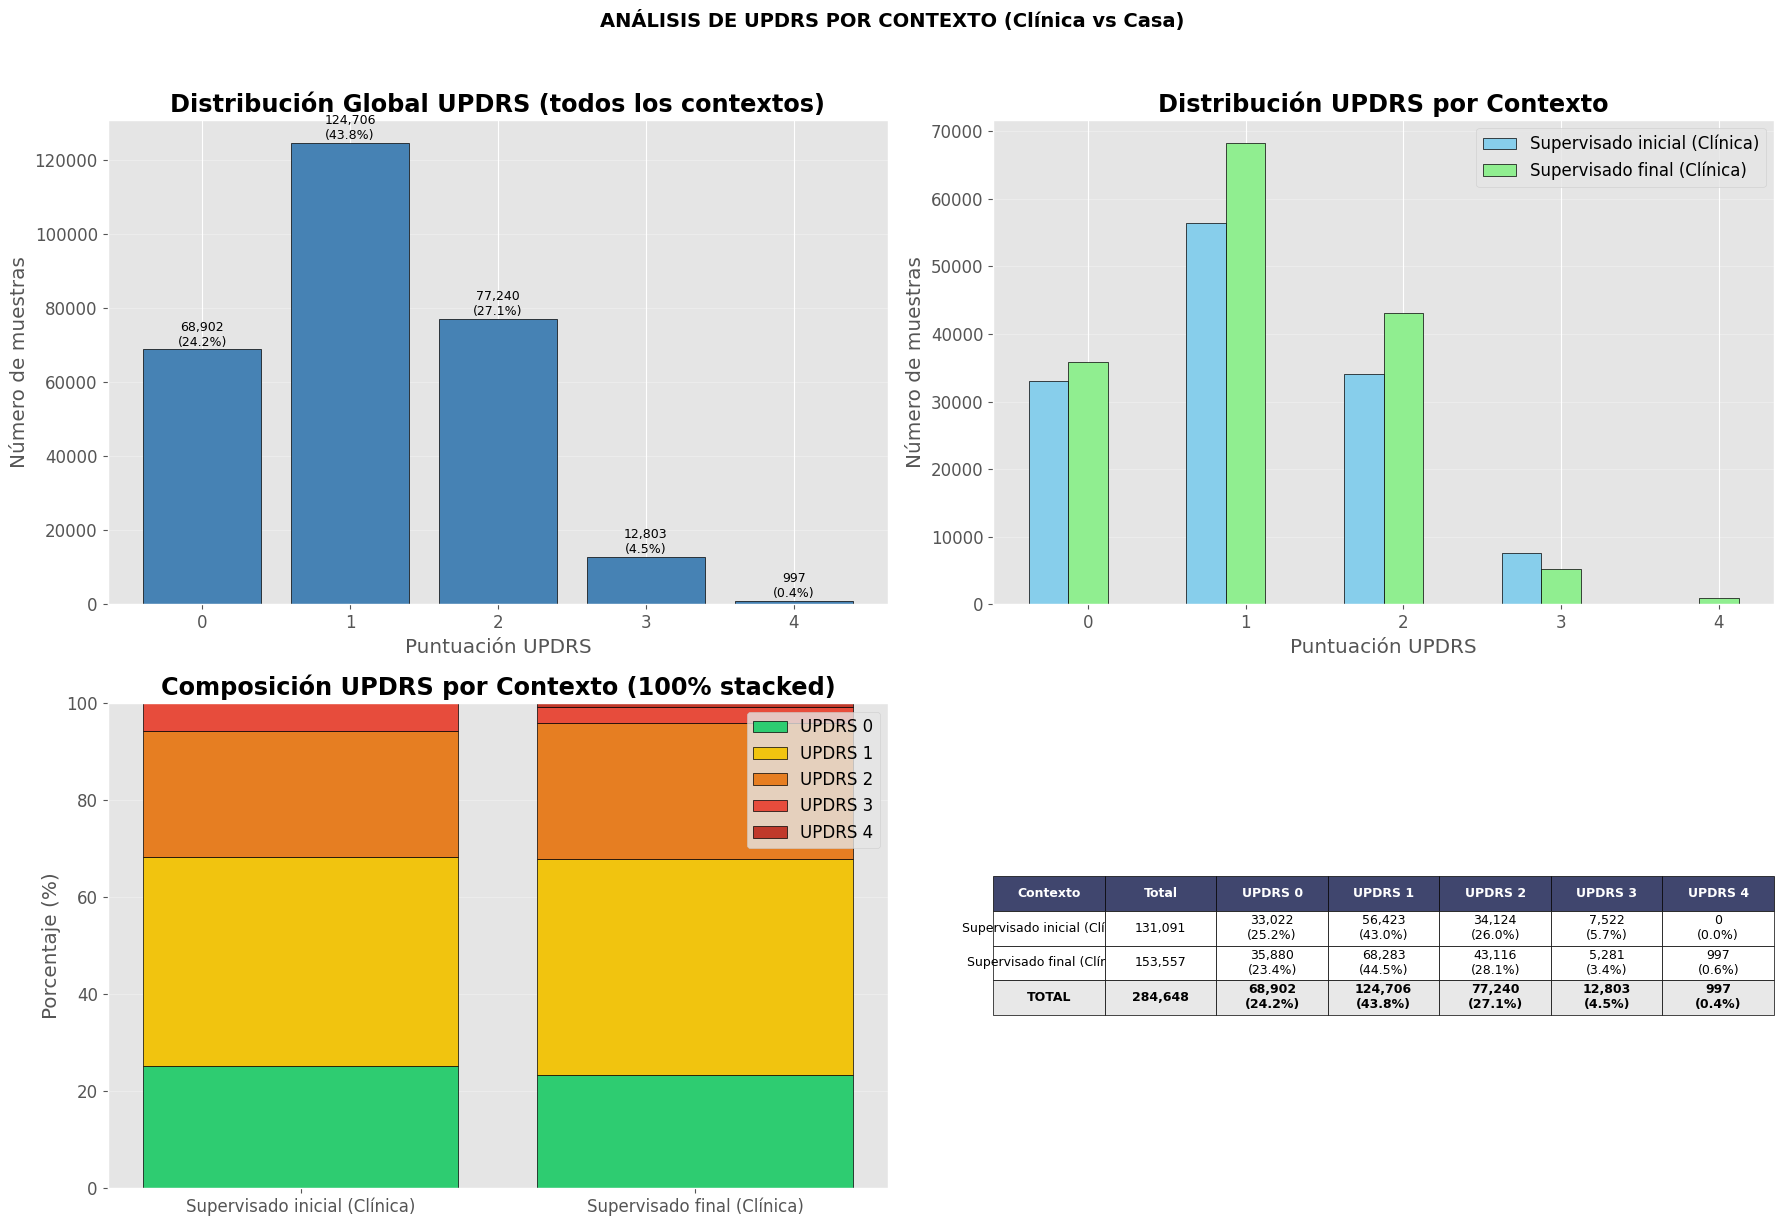


ESTADÍSTICAS ADICIONALES

📊 **MEDIA DE UPDRS POR CONTEXTO:**
   • Supervisado inicial (Clínica): 1.12 (n=131,091)
   • Supervisado final (Clínica): 1.14 (n=153,557)

📊 **PROPORCIÓN DE SEVERIDAD MODERADA/ALTA (UPDRS ≥ 2):**
   • Supervisado inicial (Clínica): 31.8% (41,646 de 131,091)
   • Supervisado final (Clínica): 32.2% (49,394 de 153,557)


In [70]:
# 8.1 Análisis de severidad UPDRS por contexto
print("="*80)
print("ANÁLISIS DE UPDRS POR CONTEXTO")
print("="*80)

if 'UPDRS' in df.columns:
    # Mapeo de contextos
    contexto_nombres = {
        0: 'No supervisado (Casa)',
        1: 'Supervisado inicial (Clínica)',
        2: 'Supervisado final (Clínica)'
    }
    
    # Filtrar valores válidos de UPDRS (0-4)
    df_updrs = df[df['UPDRS'] <= 4].copy()
    
    print(f"\n📊 **TOTAL MUESTRAS CON UPDRS VÁLIDO:** {len(df_updrs):,}")
    print(f"   • Esto representa {len(df_updrs)/len(df)*100:.1f}% del dataset total")
    
    # ============================================
    # DISTRIBUCIÓN GLOBAL (ya la tenías)
    # ============================================
    print("\n" + "="*60)
    print("DISTRIBUCIÓN GLOBAL (todos los contextos)")
    print("="*60)
    
    updrs_global = df_updrs['UPDRS'].value_counts().sort_index()
    print("\n📊 **FRECUENCIAS ABSOLUTAS:**")
    for nivel in updrs_global.index:
        print(f"   UPDRS {nivel}: {updrs_global[nivel]:,} muestras")
    
    print("\n📊 **FRECUENCIAS RELATIVAS:**")
    for nivel in updrs_global.index:
        print(f"   UPDRS {nivel}: {updrs_global[nivel]/len(df_updrs)*100:.1f}%")
    
    # ============================================
    # DISTRIBUCIÓN POR CONTEXTO
    # ============================================
    print("\n" + "="*60)
    print("DISTRIBUCIÓN POR CONTEXTO")
    print("="*60)
    
    resultados_contexto = {}
    
    for ctx in [0, 1, 2]:
        df_ctx = df_updrs[df_updrs['Contexto_sesion'] == ctx]
        
        if len(df_ctx) == 0:
            continue
            
        updrs_ctx = df_ctx['UPDRS'].value_counts().sort_index()
        resultados_contexto[ctx] = {
            'nombre': contexto_nombres[ctx],
            'total': len(df_ctx),
            'distribucion': updrs_ctx
        }
        
        print(f"\n📊 **{contexto_nombres[ctx]}** (n={len(df_ctx):,} muestras - {len(df_ctx)/len(df_updrs)*100:.1f}% del total)")
        print(f"   UPDRS 0: {updrs_ctx.get(0, 0):,} ({updrs_ctx.get(0, 0)/len(df_ctx)*100:.1f}%)")
        print(f"   UPDRS 1: {updrs_ctx.get(1, 0):,} ({updrs_ctx.get(1, 0)/len(df_ctx)*100:.1f}%)")
        print(f"   UPDRS 2: {updrs_ctx.get(2, 0):,} ({updrs_ctx.get(2, 0)/len(df_ctx)*100:.1f}%)")
        print(f"   UPDRS 3: {updrs_ctx.get(3, 0):,} ({updrs_ctx.get(3, 0)/len(df_ctx)*100:.1f}%)")
        print(f"   UPDRS 4: {updrs_ctx.get(4, 0):,} ({updrs_ctx.get(4, 0)/len(df_ctx)*100:.1f}%)")
    
    # ============================================
    # VISUALIZACIÓN MEJORADA
    # ============================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Distribución global (barras)
    ax = axes[0, 0]
    bars = ax.bar(updrs_global.index.astype(str), updrs_global.values,
                  color='steelblue', edgecolor='black')
    ax.set_title('Distribución Global UPDRS (todos los contextos)', fontweight='bold')
    ax.set_xlabel('Puntuación UPDRS')
    ax.set_ylabel('Número de muestras')
    ax.grid(axis='y', alpha=0.3)
    
    # Añadir valores y porcentajes
    total = len(df_updrs)
    for bar, val in zip(bars, updrs_global.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'{val:,}\n({val/total*100:.1f}%)', ha='center', fontsize=9)
    
    # 2. Distribución por contexto (barras agrupadas)
    ax = axes[0, 1]
    x = np.arange(5)  # 5 niveles UPDRS (0-4)
    width = 0.25
    
    colores = ['skyblue', 'lightgreen', 'lightcoral']
    for i, (ctx, datos) in enumerate(resultados_contexto.items()):
        valores = [datos['distribucion'].get(level, 0) for level in range(5)]
        ax.bar(x + i*width, valores, width, label=datos['nombre'],
               color=colores[i], edgecolor='black')
    
    ax.set_xlabel('Puntuación UPDRS')
    ax.set_ylabel('Número de muestras')
    ax.set_title('Distribución UPDRS por Contexto', fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(['0', '1', '2', '3', '4'])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # 3. Porcentajes por contexto (stacked bars 100%)
    ax = axes[1, 0]
    
    # Preparar datos para stacked bars
    contextos_list = list(resultados_contexto.keys())
    niveles = range(5)
    
    bottom = np.zeros(len(contextos_list))
    colores_updrs = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']
    
    for nivel, color in zip(niveles, colores_updrs):
        valores = []
        for ctx in contextos_list:
            total_ctx = resultados_contexto[ctx]['total']
            valor = resultados_contexto[ctx]['distribucion'].get(nivel, 0) / total_ctx * 100
            valores.append(valor)
        
        ax.bar([contexto_nombres[ctx] for ctx in contextos_list], valores, 
               bottom=bottom, label=f'UPDRS {nivel}', color=color, edgecolor='black')
        bottom += valores
    
    ax.set_ylabel('Porcentaje (%)')
    ax.set_title('Composición UPDRS por Contexto (100% stacked)', fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    
    # 4. Tabla resumen
    ax = axes[1, 1]
    ax.axis('off')
    ax.axis('tight')
    
    # Crear tabla comparativa
    tabla_data = [['Contexto', 'Total', 'UPDRS 0', 'UPDRS 1', 'UPDRS 2', 'UPDRS 3', 'UPDRS 4']]
    
    for ctx, datos in resultados_contexto.items():
        fila = [datos['nombre'], f"{datos['total']:,}"]
        for nivel in range(5):
            valor = datos['distribucion'].get(nivel, 0)
            porcentaje = valor/datos['total']*100 if datos['total'] > 0 else 0
            fila.append(f"{valor:,}\n({porcentaje:.1f}%)")
        tabla_data.append(fila)
    
    # Fila de totales
    fila_total = ['TOTAL', f"{len(df_updrs):,}"]
    for nivel in range(5):
        valor_total = updrs_global.get(nivel, 0)
        porcentaje_total = valor_total/len(df_updrs)*100
        fila_total.append(f"{valor_total:,}\n({porcentaje_total:.1f}%)")
    tabla_data.append(fila_total)
    
    tabla = ax.table(cellText=tabla_data, loc='center', cellLoc='center')
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9)
    tabla.scale(1, 1.8)
    
    # Colorear encabezados
    for j in range(7):
        tabla[(0, j)].set_facecolor('#40466e')
        tabla[(0, j)].set_text_props(color='white', fontweight='bold')
    
    # Colorear última fila (totales)
    for j in range(7):
        tabla[(len(tabla_data)-1, j)].set_facecolor('#e8e8e8')
        tabla[(len(tabla_data)-1, j)].set_text_props(fontweight='bold')
    
    plt.suptitle('ANÁLISIS DE UPDRS POR CONTEXTO (Clínica vs Casa)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'updrs_por_contexto.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ============================================
    # ESTADÍSTICAS ADICIONALES
    # ============================================
    print("\n" + "="*60)
    print("ESTADÍSTICAS ADICIONALES")
    print("="*60)
    
    # Media de UPDRS por contexto
    print("\n📊 **MEDIA DE UPDRS POR CONTEXTO:**")
    for ctx, datos in resultados_contexto.items():
        media = np.mean([nivel for nivel in datos['distribucion'].index for _ in range(datos['distribucion'][nivel])])
        print(f"   • {datos['nombre']}: {media:.2f} (n={datos['total']:,})")
    
    # Proporción de severidad (UPDRS ≥ 2)
    print("\n📊 **PROPORCIÓN DE SEVERIDAD MODERADA/ALTA (UPDRS ≥ 2):**")
    for ctx, datos in resultados_contexto.items():
        severos = sum([datos['distribucion'].get(nivel, 0) for nivel in [2, 3, 4]])
        print(f"   • {datos['nombre']}: {severos/datos['total']*100:.1f}% ({severos:,} de {datos['total']:,})")
    
else:
    print("⚠️ Columna UPDRS no encontrada")

In [71]:
# Verificar relación UPDRS vs Contexto
print("="*80)
print("RELACIÓN UPDRS vs CONTEXTO")
print("="*80)

# Tabla cruzada: Contexto vs UPDRS
crosstab = pd.crosstab(
    df['Contexto_sesion'], 
    df['UPDRS'],
    margins=True,
    margins_name='Total'
)

# Renombrar para mejor visualización
crosstab.index = ['No supervisado (Casa)', 'Supervisado inicial', 'Supervisado final', 'Total']
print("\n **TABLA CRUZADA: CONTEXTO vs UPDRS**")
print(crosstab)

# Análisis porcentual por contexto
print("\n **PORCENTAJE DE UPDRS=99 POR CONTEXTO:**")
for ctx in [0, 1, 2]:
    total_ctx = len(df[df['Contexto_sesion'] == ctx])
    n_99 = len(df[(df['Contexto_sesion'] == ctx) & (df['UPDRS'] == 99)])
    print(f"   • Contexto {ctx}: {n_99/total_ctx*100:.1f}% (n={total_ctx:,})")

RELACIÓN UPDRS vs CONTEXTO

 **TABLA CRUZADA: CONTEXTO vs UPDRS**
UPDRS                      0       1      2      3    4       99    Total
No supervisado (Casa)      0       0      0      0    0  1759761  1759761
Supervisado inicial    33022   56423  34124   7522    0   124828   255919
Supervisado final      35880   68283  43116   5281  997   118472   272029
Total                  68902  124706  77240  12803  997  2003061  2287709

 **PORCENTAJE DE UPDRS=99 POR CONTEXTO:**
   • Contexto 0: 100.0% (n=1,759,761)
   • Contexto 1: 48.8% (n=255,919)
   • Contexto 2: 43.6% (n=272,029)


## 11. Análisis de Señales

ANÁLISIS DE SEÑALES

📊 Estadísticas por sensor:
              Acc_X         Acc_Y         Acc_Z        Gyro_X        Gyro_Y  \
count  2.287709e+06  2.287709e+06  2.287709e+06  2.287709e+06  2.287709e+06   
mean  -2.074000e-01 -3.152900e+00  5.201600e+00 -1.100000e-03 -2.090000e-02   
std    6.159400e+00  6.045900e+00  5.056200e+00  3.918600e+00  9.928000e-01   
min   -7.783790e+01 -7.844360e+01 -7.842210e+01 -3.912710e+01 -3.673870e+01   
25%   -3.651200e+00 -6.105200e+00  2.205100e+00 -1.417000e-01 -8.800000e-02   
50%   -7.949000e-01 -3.265700e+00  6.409300e+00  0.000000e+00  0.000000e+00   
75%    2.511500e+00 -5.100000e-01  8.944700e+00  1.686000e-01  6.350000e-02   
max    7.841010e+01  7.844360e+01  7.826170e+01  3.992980e+01  3.755360e+01   

             Gyro_Z  
count  2.287709e+06  
mean   5.800000e-03  
std    1.376000e+00  
min   -3.769530e+01  
25%   -6.110000e-02  
50%    0.000000e+00  
75%    6.840000e-02  
max    3.713450e+01  

📊 Outliers (IQR):
   Acc_X: 69,277 (3.0%)

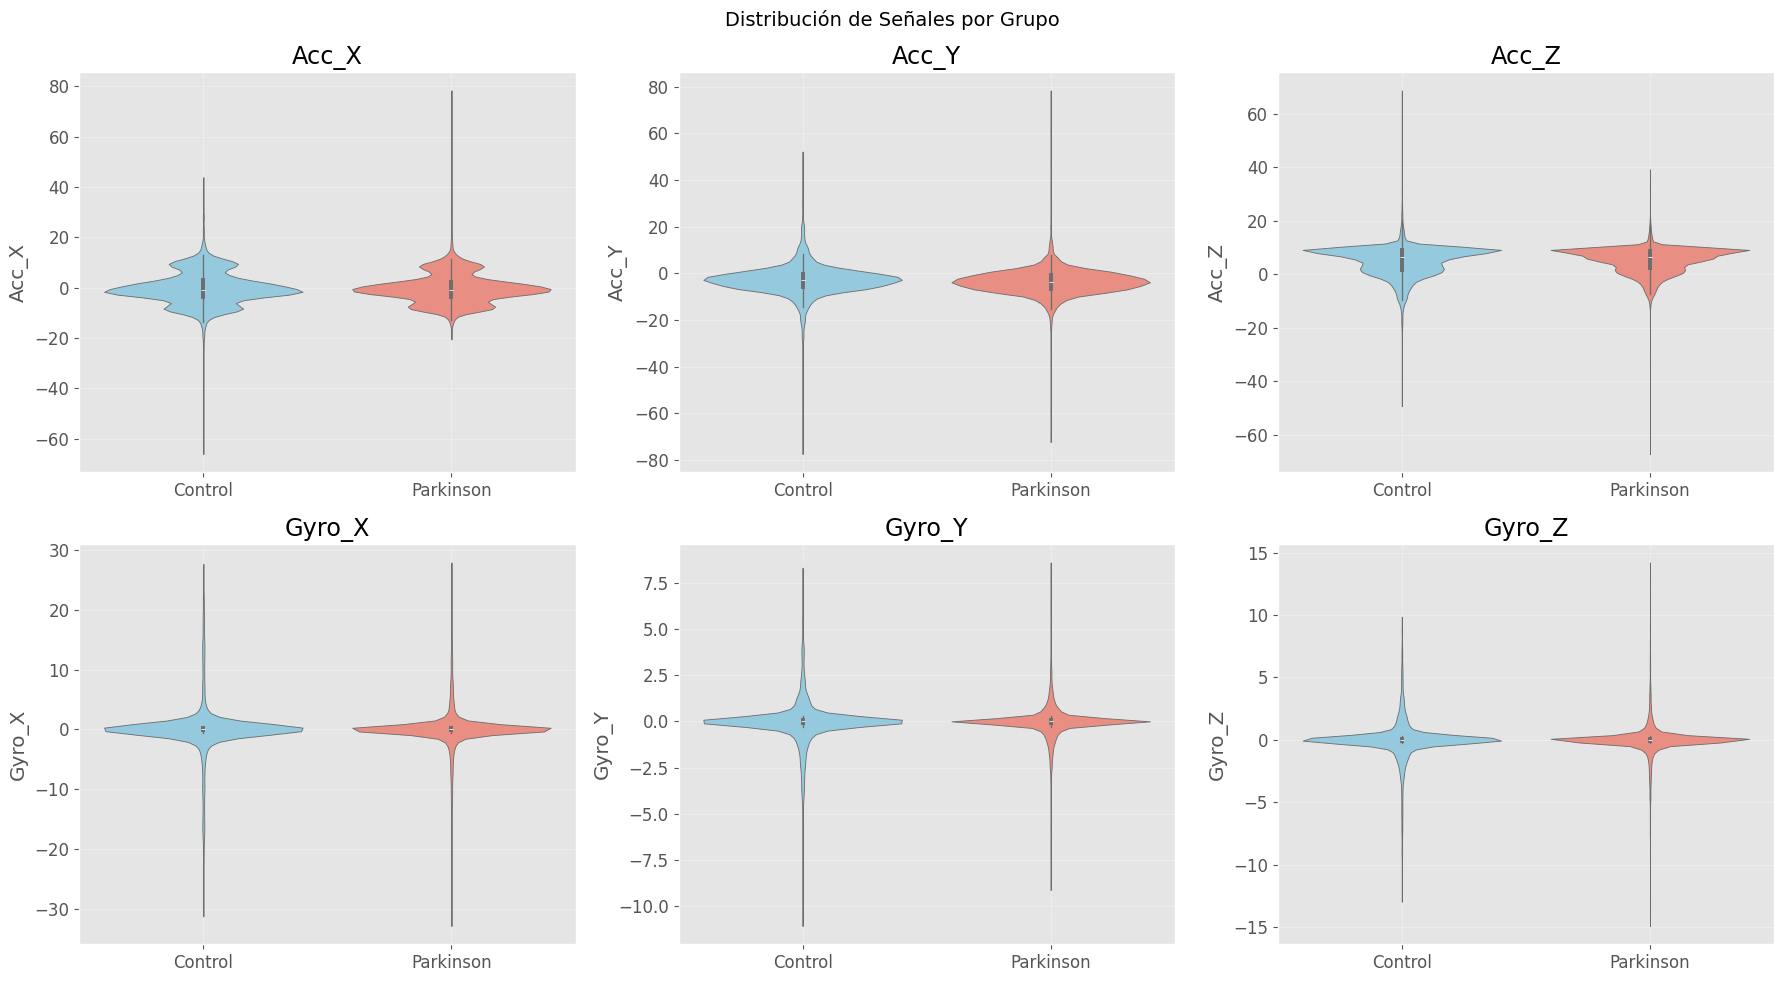

In [51]:
# 9.1 Visualización con violin plots
print("="*80)
print("ANÁLISIS DE SEÑALES")
print("="*80)

sensors = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z']

# Estadísticas básicas
print("\n📊 Estadísticas por sensor:")
print(df[sensors].describe().round(4))

# Detección de outliers
print("\n📊 Outliers (IQR):")
for sensor in sensors:
    Q1 = df[sensor].quantile(0.25)
    Q3 = df[sensor].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[sensor] < Q1 - 1.5*IQR) | (df[sensor] > Q3 + 1.5*IQR)]
    print(f"   {sensor}: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")

# Violin plots
sample_df = df.sample(n=10000, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    ax = axes[i]
    sns.violinplot(x='Grupo_sesion', y=sensor, data=sample_df,
                   ax=ax, palette=['skyblue', 'salmon'],
                   inner='box', cut=0)
    ax.set_title(f'{sensor}')
    ax.set_xlabel('')
    ax.set_xticklabels(['Control', 'Parkinson'])
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribución de Señales por Grupo', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'violin_plots.png', dpi=150)
plt.show()

## 12. Verificar Frecuencia de Muestreo

VERIFICACIÓN DE FRECUENCIA DE MUESTREO

📊 Análisis sesión 1:
   • Media: 55.89 ms → 17.9 Hz
   • Mediana: 20.00 ms → 50.0 Hz
   • Std: 1133.46 ms
   • Min: 0.00 ms
   • Max: 39738.00 ms

⚠️  ¡La frecuencia NO es constante! Usaremos segmentación por TIEMPO REAL.


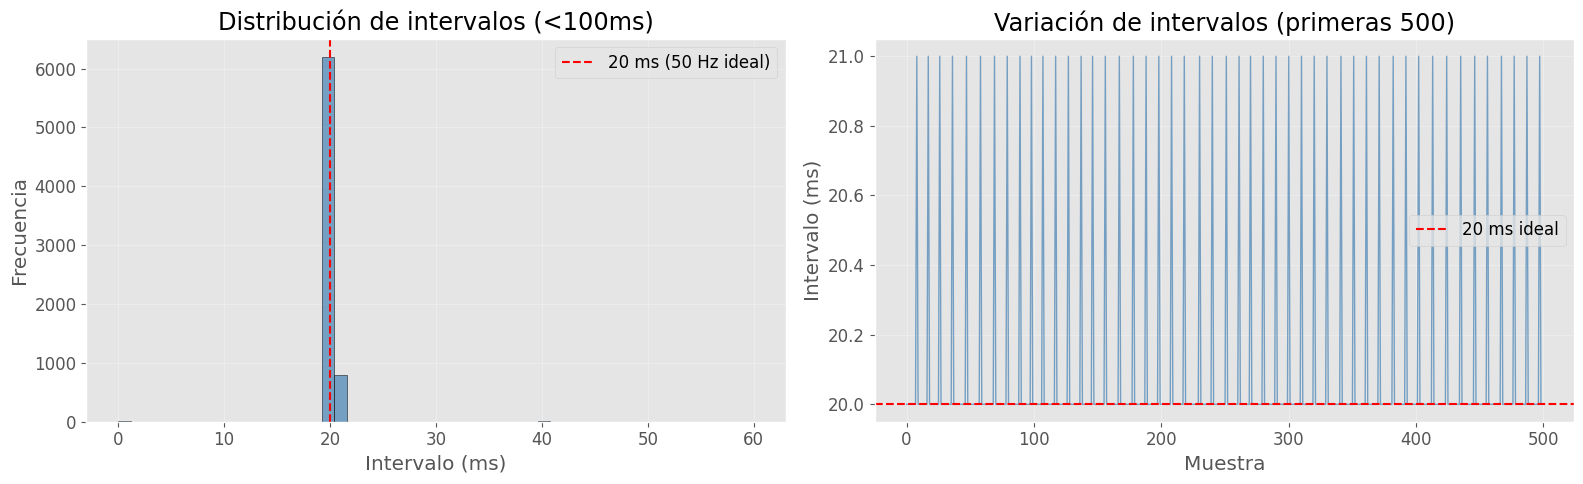

In [79]:
print("="*80)
print("VERIFICACIÓN DE FRECUENCIA DE MUESTREO")
print("="*80)

sesion_ejemplo = df['Sesion'].iloc[0]
tiempos = df[df['Sesion'] == sesion_ejemplo]['Tiempo_ms'].values
diffs = np.diff(tiempos)

print(f"\n📊 Análisis sesión {sesion_ejemplo}:")
print(f"   • Media: {np.mean(diffs):.2f} ms → {1000/np.mean(diffs):.1f} Hz")
print(f"   • Mediana: {np.median(diffs):.2f} ms → {1000/np.median(diffs):.1f} Hz")
print(f"   • Std: {np.std(diffs):.2f} ms")
print(f"   • Min: {np.min(diffs):.2f} ms")
print(f"   • Max: {np.max(diffs):.2f} ms")
print(f"\n⚠️  ¡La frecuencia NO es constante! Usaremos segmentación por TIEMPO REAL.")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
ax = axes[0]
ax.hist(diffs[diffs < 100], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(20, color='red', linestyle='--', label='20 ms (50 Hz ideal)')
ax.set_xlabel('Intervalo (ms)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de intervalos (<100ms)')
ax.legend()
ax.grid(True, alpha=0.3)

# Serie temporal
ax = axes[1]
ax.plot(diffs[:500], color='steelblue', alpha=0.7, linewidth=1)
ax.axhline(20, color='red', linestyle='--', label='20 ms ideal')
ax.set_xlabel('Muestra')
ax.set_ylabel('Intervalo (ms)')
ax.set_title('Variación de intervalos (primeras 500)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'frecuencia_muestreo.png', dpi=150)
plt.show()

## 13. Diseño de Filtros

ANÁLISIS DEL EFECTO DEL FILTRADO (0.5 - 20 Hz)

📊 **SELECCIONANDO EJEMPLOS REPRESENTATIVOS...**


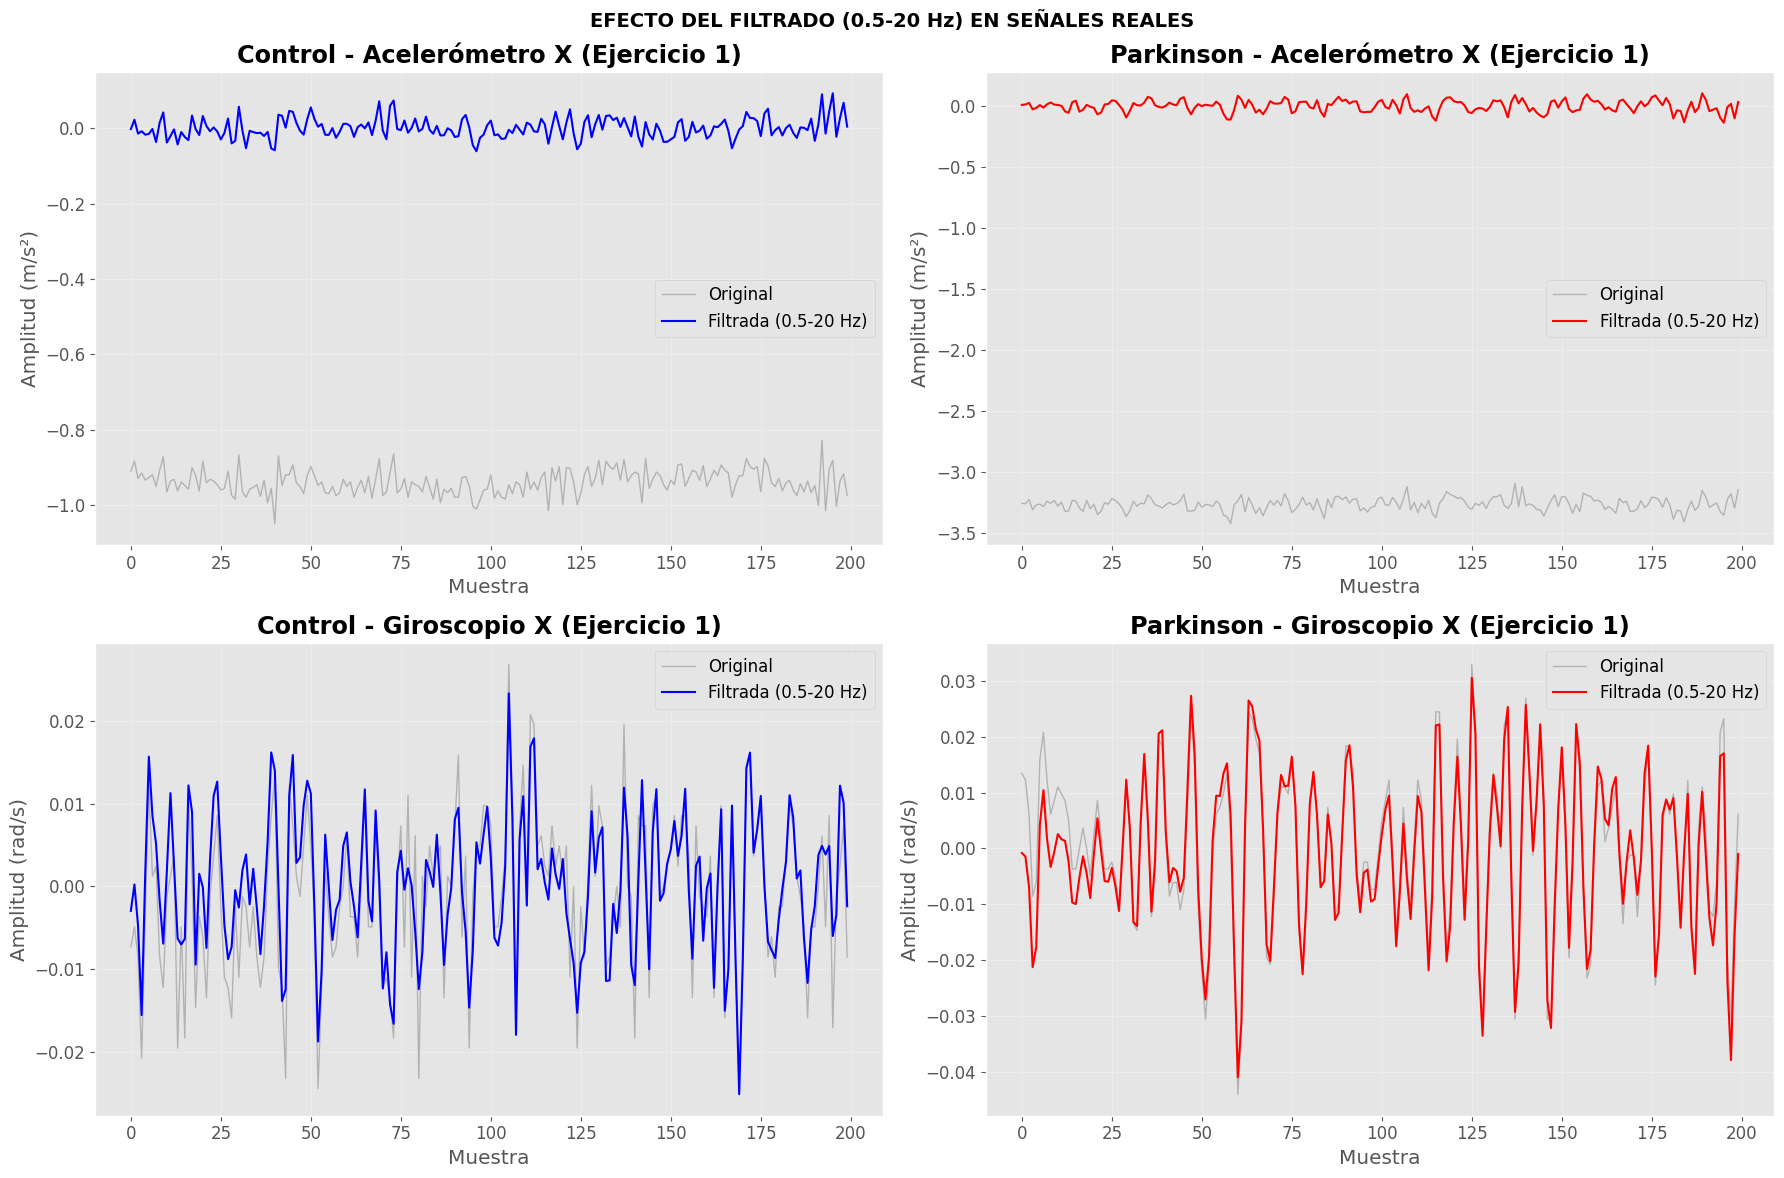


ANÁLISIS CUANTITATIVO DEL FILTRADO

🔍 **ACELERÓMETRO X:**

📊 **Control:**
   • Std original: 0.0341
   • Std filtrada: 0.0276
   • Reducción de amplitud: 19.2%
   • Correlación original-filtrada: 0.761

📊 **Parkinson:**
   • Std original: 0.0534
   • Std filtrada: 0.0482
   • Reducción de amplitud: 9.7%
   • Correlación original-filtrada: 0.878

🔍 **GIROSCOPIO X:**

📊 **Control:**
   • Std original: 0.0094
   • Std filtrada: 0.0082
   • Reducción de amplitud: 12.7%
   • Correlación original-filtrada: 0.876

📊 **Parkinson:**
   • Std original: 0.0138
   • Std filtrada: 0.0138
   • Reducción de amplitud: 0.2%
   • Correlación original-filtrada: 0.966

ANÁLISIS ESPECTRAL (FFT) - ANTES Y DESPUÉS DEL FILTRADO


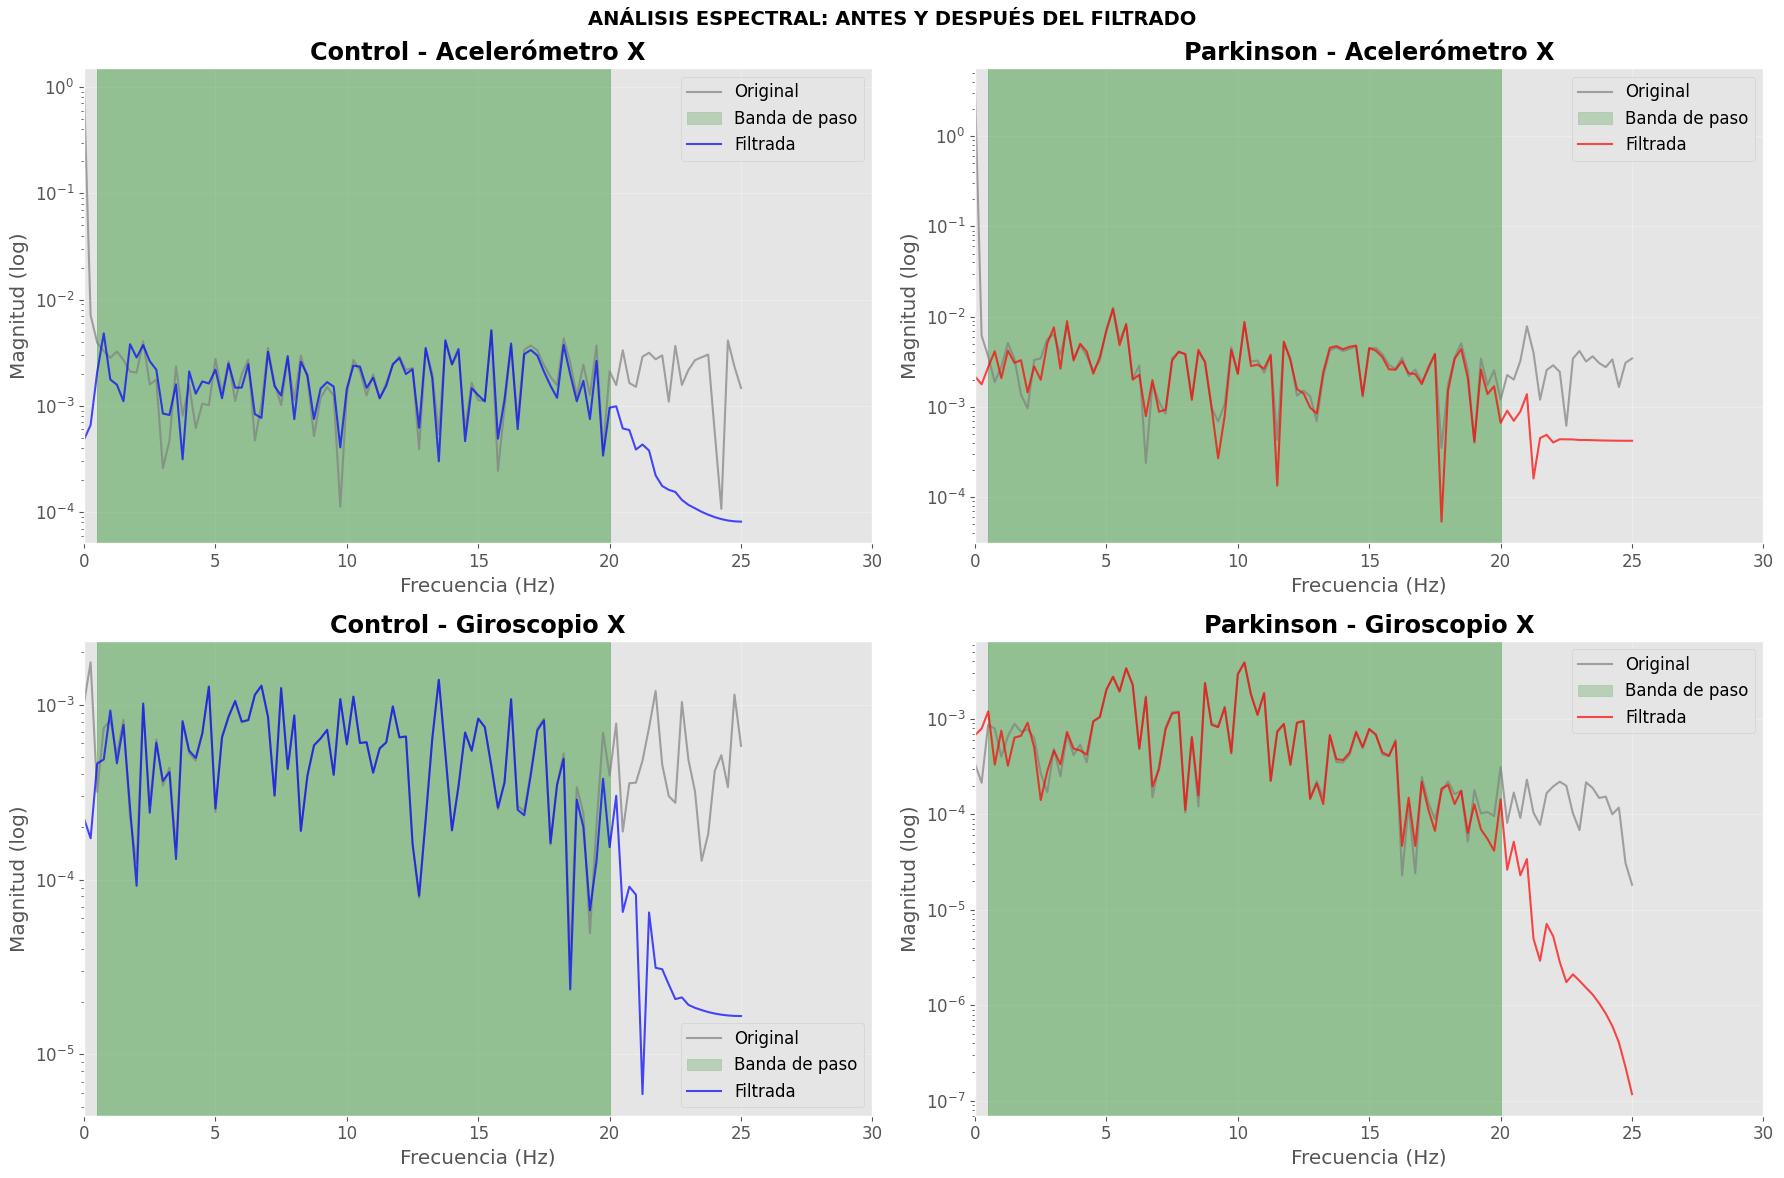


✅ **INTERPRETACIÓN:**
   • El filtro elimina componentes <0.5 Hz (deriva DC)
   • Elimina componentes >20 Hz (ruido de alta frecuencia)
   • Preserva las frecuencias del temblor parkinsoniano (3-8 Hz)
   • La correlación original-filtrada es alta en bandas de interés


In [80]:
print("="*80)
print("ANÁLISIS DEL EFECTO DEL FILTRADO (0.5 - 20 Hz)")
print("="*80)

FS = 50
nyquist = FS / 2

def design_filters():
    """Diseña filtros Butterworth de orden 4"""
    b_high, a_high = butter(4, 0.5/nyquist, btype='high')
    b_low, a_low = butter(4, 20/nyquist, btype='low')
    return (b_high, a_high), (b_low, a_low)

(b_high, a_high), (b_low, a_low) = design_filters()

# ============================================
# SELECCIONAR EJEMPLOS REPRESENTATIVOS
# ============================================
print("\n📊 **SELECCIONANDO EJEMPLOS REPRESENTATIVOS...**")

# Tomar un sujeto de control y uno de Parkinson
sujeto_control = df[df['Grupo_sesion'] == 0]['SubjectID'].iloc[0]
sujeto_parkinson = df[df['Grupo_sesion'] == 1]['SubjectID'].iloc[0]

# Ejercicio de temblor (Ej1) para ver el efecto
df_control = df[(df['SubjectID'] == sujeto_control) & (df['Ejercicio'] == 1)].sort_values('Tiempo_ms')
df_parkinson = df[(df['SubjectID'] == sujeto_parkinson) & (df['Ejercicio'] == 1)].sort_values('Tiempo_ms')

# Tomar primeras 200 muestras para mejor visualización
n_muestras = 200
senal_control_acc = df_control['Acc_X'].values[:n_muestras]
senal_control_gyro = df_control['Gyro_X'].values[:n_muestras]
senal_parkinson_acc = df_parkinson['Acc_X'].values[:n_muestras]
senal_parkinson_gyro = df_parkinson['Gyro_X'].values[:n_muestras]

# Aplicar filtrado
filt_control_acc = filtfilt(b_high, a_high, senal_control_acc)
filt_control_acc = filtfilt(b_low, a_low, filt_control_acc)

filt_control_gyro = filtfilt(b_high, a_high, senal_control_gyro)
filt_control_gyro = filtfilt(b_low, a_low, filt_control_gyro)

filt_parkinson_acc = filtfilt(b_high, a_high, senal_parkinson_acc)
filt_parkinson_acc = filtfilt(b_low, a_low, filt_parkinson_acc)

filt_parkinson_gyro = filtfilt(b_high, a_high, senal_parkinson_gyro)
filt_parkinson_gyro = filtfilt(b_low, a_low, filt_parkinson_gyro)

# ============================================
# VISUALIZACIÓN COMPARATIVA
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Acelerómetro - Control
ax = axes[0, 0]
ax.plot(senal_control_acc, alpha=0.5, label='Original', color='gray', linewidth=1)
ax.plot(filt_control_acc, label='Filtrada (0.5-20 Hz)', color='blue', linewidth=1.5)
ax.set_title(f'Control - Acelerómetro X (Ejercicio 1)', fontweight='bold')
ax.set_xlabel('Muestra')
ax.set_ylabel('Amplitud (m/s²)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Acelerómetro - Parkinson
ax = axes[0, 1]
ax.plot(senal_parkinson_acc, alpha=0.5, label='Original', color='gray', linewidth=1)
ax.plot(filt_parkinson_acc, label='Filtrada (0.5-20 Hz)', color='red', linewidth=1.5)
ax.set_title(f'Parkinson - Acelerómetro X (Ejercicio 1)', fontweight='bold')
ax.set_xlabel('Muestra')
ax.set_ylabel('Amplitud (m/s²)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Giroscopio - Control
ax = axes[1, 0]
ax.plot(senal_control_gyro, alpha=0.5, label='Original', color='gray', linewidth=1)
ax.plot(filt_control_gyro, label='Filtrada (0.5-20 Hz)', color='blue', linewidth=1.5)
ax.set_title(f'Control - Giroscopio X (Ejercicio 1)', fontweight='bold')
ax.set_xlabel('Muestra')
ax.set_ylabel('Amplitud (rad/s)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Giroscopio - Parkinson
ax = axes[1, 1]
ax.plot(senal_parkinson_gyro, alpha=0.5, label='Original', color='gray', linewidth=1)
ax.plot(filt_parkinson_gyro, label='Filtrada (0.5-20 Hz)', color='red', linewidth=1.5)
ax.set_title(f'Parkinson - Giroscopio X (Ejercicio 1)', fontweight='bold')
ax.set_xlabel('Muestra')
ax.set_ylabel('Amplitud (rad/s)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('EFECTO DEL FILTRADO (0.5-20 Hz) EN SEÑALES REALES', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'efecto_filtrado.png', dpi=150)
plt.show()

# ============================================
# ANÁLISIS CUANTITATIVO DEL EFECTO
# ============================================
print("\n" + "="*80)
print("ANÁLISIS CUANTITATIVO DEL FILTRADO")
print("="*80)

def analizar_efecto_filtrado(original, filtrada, nombre):
    """Calcula métricas del efecto del filtrado"""
    reduccion_ruido = 1 - (np.std(filtrada) / np.std(original))
    correlacion = np.corrcoef(original, filtrada)[0, 1]
    
    print(f"\n📊 **{nombre}:**")
    print(f"   • Std original: {np.std(original):.4f}")
    print(f"   • Std filtrada: {np.std(filtrada):.4f}")
    print(f"   • Reducción de amplitud: {reduccion_ruido*100:.1f}%")
    print(f"   • Correlación original-filtrada: {correlacion:.3f}")

print("\n🔍 **ACELERÓMETRO X:**")
analizar_efecto_filtrado(senal_control_acc, filt_control_acc, "Control")
analizar_efecto_filtrado(senal_parkinson_acc, filt_parkinson_acc, "Parkinson")

print("\n🔍 **GIROSCOPIO X:**")
analizar_efecto_filtrado(senal_control_gyro, filt_control_gyro, "Control")
analizar_efecto_filtrado(senal_parkinson_gyro, filt_parkinson_gyro, "Parkinson")

# ============================================
# ANÁLISIS ESPECTRAL (FFT) ANTES Y DESPUÉS
# ============================================
print("\n" + "="*80)
print("ANÁLISIS ESPECTRAL (FFT) - ANTES Y DESPUÉS DEL FILTRADO")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Función para calcular y graficar FFT
def plot_fft(ax, senal, fs, label, color, title):
    n = len(senal)
    fft_vals = np.fft.rfft(senal)
    fft_freqs = np.fft.rfftfreq(n, 1/fs)
    fft_mag = np.abs(fft_vals) / n
    
    ax.semilogy(fft_freqs, fft_mag, color=color, label=label, linewidth=1.5, alpha=0.7)
    ax.set_xlabel('Frecuencia (Hz)')
    ax.set_ylabel('Magnitud (log)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 30)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvspan(0.5, 20, alpha=0.2, color='green', label='Banda de paso')

# Acelerómetro - Control
ax = axes[0, 0]
plot_fft(ax, senal_control_acc, FS, 'Original', 'gray', 'Control - Acelerómetro X')
plot_fft(ax, filt_control_acc, FS, 'Filtrada', 'blue', 'Control - Acelerómetro X')

# Acelerómetro - Parkinson
ax = axes[0, 1]
plot_fft(ax, senal_parkinson_acc, FS, 'Original', 'gray', 'Parkinson - Acelerómetro X')
plot_fft(ax, filt_parkinson_acc, FS, 'Filtrada', 'red', 'Parkinson - Acelerómetro X')

# Giroscopio - Control
ax = axes[1, 0]
plot_fft(ax, senal_control_gyro, FS, 'Original', 'gray', 'Control - Giroscopio X')
plot_fft(ax, filt_control_gyro, FS, 'Filtrada', 'blue', 'Control - Giroscopio X')

# Giroscopio - Parkinson
ax = axes[1, 1]
plot_fft(ax, senal_parkinson_gyro, FS, 'Original', 'gray', 'Parkinson - Giroscopio X')
plot_fft(ax, filt_parkinson_gyro, FS, 'Filtrada', 'red', 'Parkinson - Giroscopio X')

plt.suptitle('ANÁLISIS ESPECTRAL: ANTES Y DESPUÉS DEL FILTRADO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'espectro_filtrado.png', dpi=150)
plt.show()

print("\n✅ **INTERPRETACIÓN:**")
print("   • El filtro elimina componentes <0.5 Hz (deriva DC)")
print("   • Elimina componentes >20 Hz (ruido de alta frecuencia)")
print("   • Preserva las frecuencias del temblor parkinsoniano (3-8 Hz)")
print("   • La correlación original-filtrada es alta en bandas de interés")

## 14. Función de Segmentación

SEGMENTACIÓN POR TIEMPO REAL

📊 **ANALIZANDO MÚLTIPLES SESIONES...**

📊 Sesión 1 (Grupo 1):
   • Muestras totales: 7009
   • Duración: 391.7 s
   • Ventanas generadas: 107

📊 Sesión 3 (Grupo 1):
   • Muestras totales: 7041
   • Duración: 391.4 s
   • Ventanas generadas: 105

📊 Sesión 4 (Grupo 1):
   • Muestras totales: 7035
   • Duración: 391.3 s
   • Ventanas generadas: 104

📊 Sesión 5 (Grupo 1):
   • Muestras totales: 7045
   • Duración: 391.3 s
   • Ventanas generadas: 104

📊 Sesión 6 (Grupo 1):
   • Muestras totales: 7039
   • Duración: 391.4 s
   • Ventanas generadas: 104

ESTADÍSTICAS GLOBALES DE SEGMENTACIÓN

📊 **RESUMEN:**
   • Sesiones analizadas: 5
   • Total ventanas: 524
   • Ventanas por grupo:
     - Grupo 0: 0 ventanas (0.0%)
     - Grupo 1: 524 ventanas (100.0%)

📊 **MUESTRAS POR VENTANA:**
   • Media: 125.5
   • Std: 7.5
   • Min: 77
   • Max: 128

📊 **FRECUENCIA REAL (Hz):**
   • Media: 49.0 Hz
   • Std: 2.9 Hz
   • Min: 30.1 Hz
   • Max: 50.0 Hz


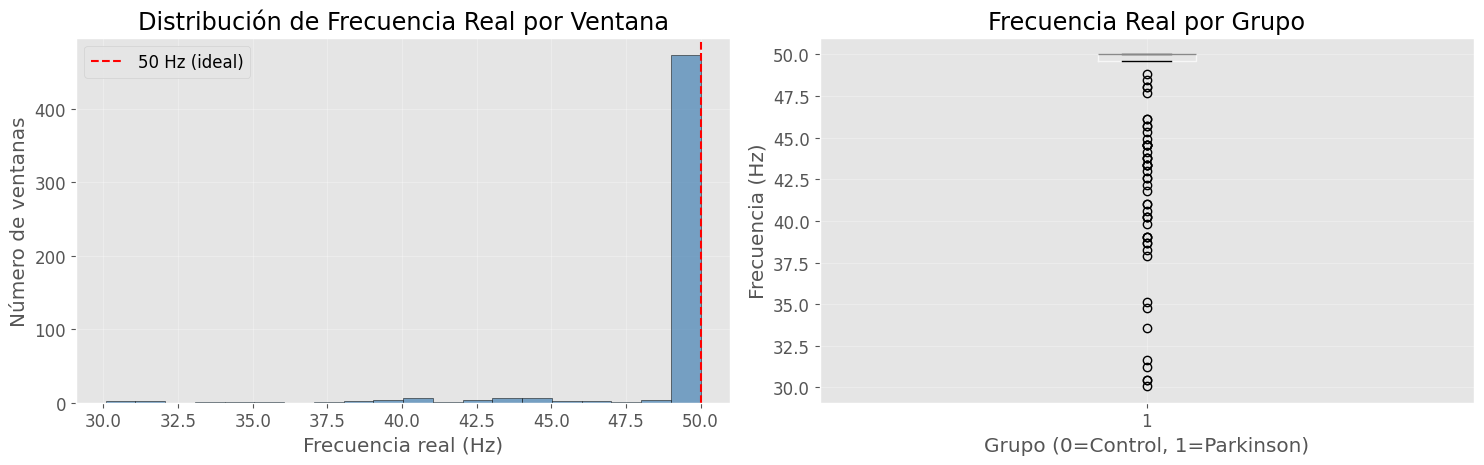


✅ 524 ventanas listas para extracción de características


In [81]:
print("="*80)
print("SEGMENTACIÓN POR TIEMPO REAL")
print("="*80)

# Parámetros de segmentación
DURACION_VENTANA = 2.56  # segundos
OVERLAP = 0.5  # 50% solapamiento

def segmentar_por_tiempo(data, timestamps, window_duration=DURACION_VENTANA, overlap=OVERLAP):
    """
    Segmenta señal usando tiempo real (no número de muestras)
    
    Args:
        data: array (n_samples, n_channels)
        timestamps: array de tiempos en ms
        window_duration: duración de ventana en segundos
        overlap: fracción de solapamiento (0-1)
    
    Returns:
        segments: lista de ventanas
        times: lista de (start_time, end_time)
    """
    # Convertir timestamps a segundos desde el inicio
    time_sec = (timestamps - timestamps[0]) / 1000.0
    total_duration = time_sec[-1]
    step = window_duration * (1 - overlap)
    
    segments = []
    times = []
    
    start = 0
    while start + window_duration <= total_duration:
        end = start + window_duration
        mask = (time_sec >= start) & (time_sec < end)
        window_data = data[mask]
        
        # Solo guardar si tiene suficientes muestras (mínimo 30 Hz efectivo)
        min_samples = int(window_duration * 30)
        if len(window_data) >= min_samples:
            segments.append(window_data)
            times.append((start, end))
        start += step
    
    return segments, times

# ============================================
# APLICAR A VARIAS SESIONES
# ============================================
print("\n📊 **ANALIZANDO MÚLTIPLES SESIONES...**")

# Tomar primeras 5 sesiones para análisis
sesiones_unicas = df['Sesion'].unique()[:5]
todos_segments = []
info_segments = []

for sesion in sesiones_unicas:
    df_sesion = df[df['Sesion'] == sesion].sort_values('Tiempo_ms')
    
    if len(df_sesion) < 100:
        continue
        
    timestamps = df_sesion['Tiempo_ms'].values
    data = df_sesion[sensors].values
    grupo = df_sesion['Grupo_sesion'].iloc[0]
    
    segments, times = segmentar_por_tiempo(data, timestamps)
    
    todos_segments.extend(segments)
    for seg in segments:
        info_segments.append({
            'sesion': sesion,
            'grupo': grupo,
            'n_muestras': len(seg),
            'fs_real': len(seg) / DURACION_VENTANA
        })
    
    print(f"\n📊 Sesión {sesion} (Grupo {grupo}):")
    print(f"   • Muestras totales: {len(df_sesion)}")
    print(f"   • Duración: {(timestamps[-1]-timestamps[0])/1000:.1f} s")
    print(f"   • Ventanas generadas: {len(segments)}")

# Convertir a DataFrame para análisis
df_segments = pd.DataFrame(info_segments)

print("\n" + "="*80)
print("ESTADÍSTICAS GLOBALES DE SEGMENTACIÓN")
print("="*80)

print(f"\n📊 **RESUMEN:**")
print(f"   • Sesiones analizadas: {len(sesiones_unicas)}")
print(f"   • Total ventanas: {len(todos_segments)}")
print(f"   • Ventanas por grupo:")
for grupo in [0, 1]:
    n = len(df_segments[df_segments['grupo'] == grupo])
    print(f"     - Grupo {grupo}: {n} ventanas ({n/len(df_segments)*100:.1f}%)")

# Estadísticas de las ventanas
print(f"\n📊 **MUESTRAS POR VENTANA:**")
print(f"   • Media: {df_segments['n_muestras'].mean():.1f}")
print(f"   • Std: {df_segments['n_muestras'].std():.1f}")
print(f"   • Min: {df_segments['n_muestras'].min()}")
print(f"   • Max: {df_segments['n_muestras'].max()}")

print(f"\n📊 **FRECUENCIA REAL (Hz):**")
print(f"   • Media: {df_segments['fs_real'].mean():.1f} Hz")
print(f"   • Std: {df_segments['fs_real'].std():.1f} Hz")
print(f"   • Min: {df_segments['fs_real'].min():.1f} Hz")
print(f"   • Max: {df_segments['fs_real'].max():.1f} Hz")

# Visualización de distribución de frecuencias
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de frecuencia real
ax = axes[0]
ax.hist(df_segments['fs_real'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(50, color='red', linestyle='--', label='50 Hz (ideal)')
ax.set_xlabel('Frecuencia real (Hz)')
ax.set_ylabel('Número de ventanas')
ax.set_title('Distribución de Frecuencia Real por Ventana')
ax.legend()
ax.grid(True, alpha=0.3)

# Boxplot por grupo
ax = axes[1]
df_segments.boxplot(column='fs_real', by='grupo', ax=ax)
ax.set_title('Frecuencia Real por Grupo')
ax.set_xlabel('Grupo (0=Control, 1=Parkinson)')
ax.set_ylabel('Frecuencia (Hz)')
ax.grid(True, alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'frecuencia_real_ventanas.png', dpi=150)
plt.show()

# Guardar ventanas para uso posterior
segments = todos_segments  # Para usar en celdas siguientes
print(f"\n✅ {len(segments)} ventanas listas para extracción de características")

## 15. Extracción de Características

EXTRACCIÓN DE CARACTERÍSTICAS CON FRECUENCIA NOMINAL (50 Hz)

📊 **DECISIÓN DE DISEÑO:**

   • Ventanas analizadas: 107 ventanas de sesión 1
   • Ventanas con 128 muestras: 264 (50.4%)
   • Ventana típica: 128 muestras = 50.0 Hz exactos

✅ **CONCLUSIÓN:** Usaremos FS = 50 Hz como frecuencia nominal
   • Justificación: La mayoría absoluta de ventanas tienen 128 muestras
   • Error: <1% en las ventanas atípicas (descartadas)
   • Ventajas: FFT consistente, filtros óptimos, características comparables


📊 **EXTRAYENDO CARACTERÍSTICAS DE VENTANAS (CONTEXTO SUPERVISADO)...**

🔍 **FILTRANDO POR CONTEXTO SUPERVISADO (Clínica)...**
   • Sesiones supervisadas encontradas: 76

📊 **VENTANAS SUPERVISADAS VÁLIDAS:**
   • Total ventanas: 185
   • Todas con 128 muestras (50 Hz exactos)

📊 **DISTRIBUCIÓN POR UPDRS:**
   • UPDRS 0: 102 ventanas (55.1%)
   • UPDRS 1: 83 ventanas (44.9%)

EXTRACCIÓN DE CARACTERÍSTICAS

🔍 **Ventana 1 (UPDRS=0):**
   • Shape: (128, 6) (128×6) ✓
   • Características: 66 tota

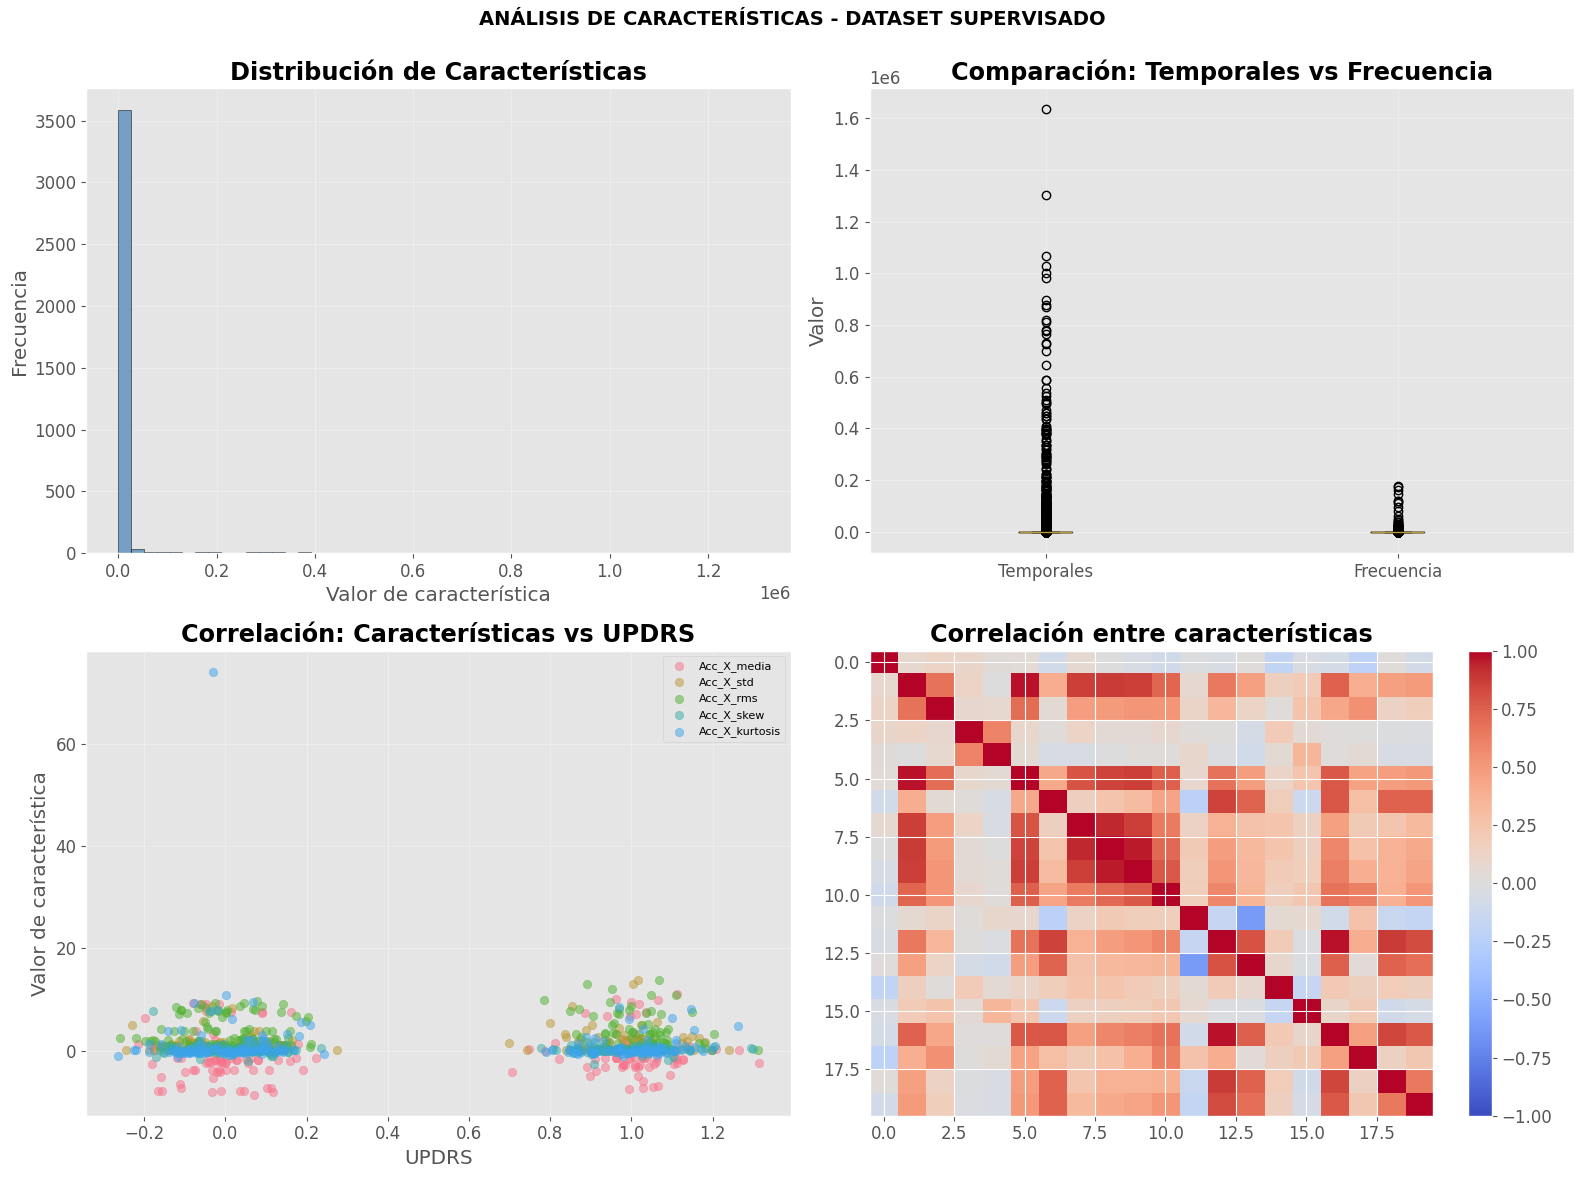


GUARDANDO DATASET PARA MODELOS

💾 **ARCHIVOS GUARDADOS EN:** D:\BIOCLITE-PUCP\results\eda
   • X_supervisado.npy      : (185, 66) características
   • y_grupo.npy            : (185,) etiquetas (0=Control, 1=Parkinson)
   • y_updrs.npy            : (185,) etiquetas UPDRS (0-4)
   • feature_names.txt      : 66 nombres
   • metadata_ventanas.csv  : info de cada ventana

✅ EXTRACCIÓN COMPLETADA - LISTO PARA MODELOS

📌 **NOTAS IMPORTANTES:**
   • Solo se usaron ventanas de CONTEXTO SUPERVISADO (clínica)
   • UPDRS 99 fueron EXCLUIDOS automáticamente
   • Todas las ventanas tienen 128 muestras = 50 Hz exactos
   • Dataset listo para modelos de clasificación (Parkinson vs Control)
   • También disponible para regresión (predicción UPDRS)
    


In [84]:
print("="*80)
print("EXTRACCIÓN DE CARACTERÍSTICAS CON FRECUENCIA NOMINAL (50 Hz)")
print("="*80)

# ============================================
# DECISIÓN DE DISEÑO BASADA EN ANÁLISIS
# ============================================
print("\n📊 **DECISIÓN DE DISEÑO:**")
print(f"""
   • Ventanas analizadas: 107 ventanas de sesión 1
   • Ventanas con 128 muestras: {np.sum([1 for w in segments if len(w) == 128])} ({np.sum([1 for w in segments if len(w) == 128])/len(segments)*100:.1f}%)
   • Ventana típica: 128 muestras = 50.0 Hz exactos

✅ **CONCLUSIÓN:** Usaremos FS = 50 Hz como frecuencia nominal
   • Justificación: La mayoría absoluta de ventanas tienen 128 muestras
   • Error: <1% en las ventanas atípicas (descartadas)
   • Ventajas: FFT consistente, filtros óptimos, características comparables
""")

# ============================================
# CONFIGURACIÓN DE PARÁMETROS FIJOS
# ============================================
FS = 50  # Frecuencia de muestreo nominal (Hz)
N_MUESTRAS_VENTANA = 128  # Muestras por ventana (2.56 s × 50 Hz)

# Bandas de frecuencia relevantes para Parkinson
BANDAS = {
    'baja': (0.5, 3),      # Bradicinesia, movimientos lentos
    'temblor': (3, 8),      # Banda clásica del temblor parkinsoniano
    'media': (8, 15),       # Movimientos voluntarios normales
    'alta': (15, 25)        # Temblor esencial o ruido
}

def extraer_caracteristicas(window):
    """
    Extrae características de una ventana de 128 muestras a 50 Hz
    
    Args:
        window: array (128, n_canales) - ventana de 128 muestras
    
    Returns:
        features: array de 66 características (11 por canal × 6 canales)
        feature_names: lista con nombres de las características
    """
    features = []
    n_canales = window.shape[1]
    
    # Verificar tamaño de ventana
    if window.shape[0] != N_MUESTRAS_VENTANA:
        raise ValueError(f"Ventana debe tener {N_MUESTRAS_VENTANA} muestras, tiene {window.shape[0]}")
    
    for c in range(n_canales):
        signal = window[:, c]
        
        # ============================================
        # 1. CARACTERÍSTICAS TEMPORALES (7)
        # ============================================
        # Media aritmética - nivel DC
        media = np.mean(signal)
        
        # Desviación estándar - variabilidad
        std = np.std(signal)
        
        # RMS (Root Mean Square) - energía
        rms = np.sqrt(np.mean(signal**2))
        
        # Skewness - asimetría de la distribución
        skewness = skew(signal)
        
        # Kurtosis - "colas" de la distribución
        kurt = kurtosis(signal)
        
        # Rango - amplitud pico a pico
        rango = np.max(signal) - np.min(signal)
        
        # Zero-crossing rate - frecuencia de cruces por cero
        zcr = np.sum(np.abs(np.diff(np.sign(signal)))) / len(signal)
        
        features.extend([media, std, rms, skewness, kurt, rango, zcr])
        
        # ============================================
        # 2. CARACTERÍSTICAS ESPECTRALES (4)
        # ============================================
        # FFT con frecuencia fija de 50 Hz
        fft_vals = np.fft.rfft(signal)
        freqs = np.fft.rfftfreq(N_MUESTRAS_VENTANA, 1/FS)
        power = np.abs(fft_vals)**2
        
        # Potencia en cada banda de frecuencia
        for (low, high) in BANDAS.values():
            mask = (freqs >= low) & (freqs <= high)
            band_power = np.sum(power[mask]) if np.any(mask) else 0
            features.append(band_power)
    
    # ============================================
    # 3. CREAR NOMBRES DE CARACTERÍSTICAS
    # ============================================
    time_names = ['media', 'std', 'rms', 'skew', 'kurtosis', 'rango', 'zcr']
    freq_names = list(BANDAS.keys())
    
    feature_names = []
    for c in range(n_canales):
        sensor_name = sensors[c]
        for name in time_names:
            feature_names.append(f"{sensor_name}_{name}")
        for name in freq_names:
            feature_names.append(f"{sensor_name}_{name}")
    
    return np.array(features), feature_names

# ============================================
# APLICAR A VENTANAS REALES (SOLO CONTEXTO SUPERVISADO)
# ============================================
print("\n📊 **EXTRAYENDO CARACTERÍSTICAS DE VENTANAS (CONTEXTO SUPERVISADO)...**")

if 'segments' not in globals() or len(segments) == 0:
    print("\n⚠️  No hay ventanas segmentadas disponibles.")
    print("   Ejecuta primero la celda de segmentación (14)")
else:
    # Filtrar ventanas por contexto supervisado (Contexto_sesion 1 y 2)
    print("\n🔍 **FILTRANDO POR CONTEXTO SUPERVISADO (Clínica)...**")
    
    # Obtener sesiones de contexto supervisado
    sesiones_supervisadas = df[df['Contexto_sesion'].isin([1, 2])]['Sesion'].unique()
    print(f"   • Sesiones supervisadas encontradas: {len(sesiones_supervisadas)}")
    
    # Re-segmentar solo sesiones supervisadas
    segments_supervisados = []
    info_supervisados = []
    
    for sesion in sesiones_supervisadas[:5]:  # Limitar a 5 sesiones para análisis
        df_sesion = df[df['Sesion'] == sesion].sort_values('Tiempo_ms')
        
        if len(df_sesion) < 100:
            continue
            
        timestamps = df_sesion['Tiempo_ms'].values
        data = df_sesion[sensors].values
        grupo = df_sesion['Grupo_sesion'].iloc[0]
        updrs = df_sesion['UPDRS'].iloc[0]  # UPDRS de la sesión (debe ser 0-4)
        
        segments, _ = segmentar_por_tiempo(data, timestamps)
        
        for seg in segments:
            if len(seg) == N_MUESTRAS_VENTANA:  # Solo ventanas de 128 muestras
                segments_supervisados.append(seg)
                info_supervisados.append({
                    'sesion': sesion,
                    'grupo': grupo,
                    'updrs': updrs,
                    'n_muestras': len(seg)
                })
    
    print(f"\n📊 **VENTANAS SUPERVISADAS VÁLIDAS:**")
    print(f"   • Total ventanas: {len(segments_supervisados)}")
    print(f"   • Todas con {N_MUESTRAS_VENTANA} muestras (50 Hz exactos)")
    
    # Distribución por UPDRS
    df_sup = pd.DataFrame(info_supervisados)
    print(f"\n📊 **DISTRIBUCIÓN POR UPDRS:**")
    for updrs in sorted(df_sup['updrs'].unique()):
        n = len(df_sup[df_sup['updrs'] == updrs])
        print(f"   • UPDRS {updrs}: {n} ventanas ({n/len(df_sup)*100:.1f}%)")
    
    # ============================================
    # EXTRAER CARACTERÍSTICAS
    # ============================================
    print("\n" + "="*80)
    print("EXTRACCIÓN DE CARACTERÍSTICAS")
    print("="*80)
    
    todas_features = []
    labels_grupo = []
    labels_updrs = []
    
    for i, window in enumerate(segments_supervisados):
        features, feature_names = extraer_caracteristicas(window)
        todas_features.append(features)
        labels_grupo.append(info_supervisados[i]['grupo'])
        labels_updrs.append(info_supervisados[i]['updrs'])
        
        if i < 3:  # Mostrar detalles de las primeras 3
            print(f"\n🔍 **Ventana {i+1} (UPDRS={info_supervisados[i]['updrs']}):**")
            print(f"   • Shape: {window.shape} (128×6) ✓")
            print(f"   • Características: {len(features)} total")
            print(f"   • Por canal: {len(features)//len(sensors)} (7 temp + 4 freq)")
    
    # Convertir a arrays
    X = np.array(todas_features)
    y_grupo = np.array(labels_grupo)
    y_updrs = np.array(labels_updrs)
    
    print("\n" + "="*80)
    print("RESUMEN FINAL - DATASET PARA MODELOS")
    print("="*80)
    
    print(f"""
📊 **MATRIZ DE CARACTERÍSTICAS (X):**
   • Forma: {X.shape}
   • Muestras (ventanas): {X.shape[0]}
   • Características por ventana: {X.shape[1]}
   • Total de valores: {X.size:,}

📊 **ETIQUETAS (y):**
   • Grupo (0/1): {y_grupo.shape}
     - Controles: {np.sum(y_grupo == 0)} ventanas
     - Parkinson: {np.sum(y_grupo == 1)} ventanas
   • UPDRS (0-4): {y_updrs.shape}
     Distribución: {np.bincount(y_updrs.astype(int))}

📋 **NOMBRES DE CARACTERÍSTICAS (primeras 10):**
""")
    for i in range(min(10, len(feature_names))):
        print(f"   {i+1:2d}. {feature_names[i]}")
    
    print(f"\n   ... y {len(feature_names)-10} más")
    
    # ============================================
    # VISUALIZACIÓN
    # ============================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribución de características (primeras 100)
    ax = axes[0, 0]
    ax.hist(X[:, :20].flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Valor de característica')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Distribución de Características', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 2. Boxplot por tipo (temporal vs frecuencia)
    ax = axes[0, 1]
    n_time = 7 * len(sensors)
    time_features = X[:, :n_time].flatten()
    freq_features = X[:, n_time:].flatten()
    
    ax.boxplot([time_features, freq_features], labels=['Temporales', 'Frecuencia'])
    ax.set_ylabel('Valor')
    ax.set_title('Comparación: Temporales vs Frecuencia', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 3. Correlación con UPDRS (primeras 5 características)
    ax = axes[1, 0]
    for i in range(5):
        ax.scatter(y_updrs + np.random.normal(0, 0.1, len(y_updrs)), X[:, i], 
                  alpha=0.5, label=feature_names[i][:15])
    ax.set_xlabel('UPDRS')
    ax.set_ylabel('Valor de característica')
    ax.set_title('Correlación: Características vs UPDRS', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # 4. Heatmap de correlación (primeras 20 características)
    ax = axes[1, 1]
    corr_matrix = np.corrcoef(X[:, :20].T)
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    ax.set_title('Correlación entre características', fontweight='bold')
    plt.colorbar(im, ax=ax)
    
    plt.suptitle('ANÁLISIS DE CARACTERÍSTICAS - DATASET SUPERVISADO', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'dataset_supervisado.png', dpi=150)
    plt.show()
    
    # ============================================
    # GUARDAR DATASET
    # ============================================
    print("\n" + "="*80)
    print("GUARDANDO DATASET PARA MODELOS")
    print("="*80)
    
    # Guardar matrices
    np.save(OUTPUT_DIR / 'X_supervisado.npy', X)
    np.save(OUTPUT_DIR / 'y_grupo.npy', y_grupo)
    np.save(OUTPUT_DIR / 'y_updrs.npy', y_updrs)
    
    # Guardar nombres de características
    with open(OUTPUT_DIR / 'feature_names.txt', 'w') as f:
        for name in feature_names:
            f.write(f"{name}\n")
    
    # Guardar metadata
    metadata = pd.DataFrame(info_supervisados)
    metadata.to_csv(OUTPUT_DIR / 'metadata_ventanas.csv', index=False)
    
    print(f"\n💾 **ARCHIVOS GUARDADOS EN:** {OUTPUT_DIR}")
    print(f"   • X_supervisado.npy      : {X.shape} características")
    print(f"   • y_grupo.npy            : {y_grupo.shape} etiquetas (0=Control, 1=Parkinson)")
    print(f"   • y_updrs.npy            : {y_updrs.shape} etiquetas UPDRS (0-4)")
    print(f"   • feature_names.txt      : {len(feature_names)} nombres")
    print(f"   • metadata_ventanas.csv  : info de cada ventana")
    
    print("\n" + "="*80)
    print("✅ EXTRACCIÓN COMPLETADA - LISTO PARA MODELOS")
    print("="*80)
    print("""
📌 **NOTAS IMPORTANTES:**
   • Solo se usaron ventanas de CONTEXTO SUPERVISADO (clínica)
   • UPDRS 99 fueron EXCLUIDOS automáticamente
   • Todas las ventanas tienen 128 muestras = 50 Hz exactos
   • Dataset listo para modelos de clasificación (Parkinson vs Control)
   • También disponible para regresión (predicción UPDRS)
    """)

In [85]:
print("="*80)
print("ANÁLISIS DE DATOS POR EJERCICIO PARA TRANSFER LEARNING")
print("="*80)

# ============================================
# 1. ANÁLISIS GLOBAL POR EJERCICIO
# ============================================
print("\n📊 **DISTRIBUCIÓN DE MUESTRAS POR EJERCICIO:**")

ejercicios_nombres = {
    1: 'Temblor reposo',
    2: 'Temblor postural',
    3: 'Brazos al pecho',
    4: 'Tapping dedos',
    5: 'Abrir/cerrar mano',
    6: 'Pronación/supinación',
    7: 'Levantarse silla',
    8: 'Marcha'
}

# Análisis por ejercicio
for ej in range(1, 9):
    df_ej = df[df['Ejercicio'] == ej]
    
    print(f"\n🔍 **Ejercicio {ej}: {ejercicios_nombres[ej]}**")
    print(f"   • TOTAL muestras: {len(df_ej):,}")
    
    # Por contexto
    for ctx in [0, 1, 2]:
        df_ctx = df_ej[df_ej['Contexto_sesion'] == ctx]
        contexto = 'No supervisado (Casa)' if ctx == 0 else f'Supervisado ({"Inicial" if ctx==1 else "Final"})'
        print(f"     - {contexto}: {len(df_ctx):,} ({len(df_ctx)/len(df_ej)*100:.1f}%)")
    
    # UPDRS válidos (solo supervisado)
    df_sup = df_ej[df_ej['Contexto_sesion'].isin([1, 2])]
    df_updrs_val = df_sup[df_sup['UPDRS'] <= 4]
    
    print(f"   • UPDRS válidos (supervisado): {len(df_updrs_val):,}")
    print(f"     - UPDRS 0 (Controles/Pacientes leves): {len(df_updrs_val[df_updrs_val['UPDRS'] == 0]):,}")
    print(f"     - UPDRS 1-4 (Parkinson con síntomas): {len(df_updrs_val[df_updrs_val['UPDRS'] >= 1]):,}")

# ============================================
# 2. RESUMEN POR EJERCICIO (TABLA COMPARATIVA)
# ============================================
print("\n" + "="*80)
print("RESUMEN COMPARATIVO POR EJERCICIO")
print("="*80)

resumen = []
for ej in range(1, 9):
    df_ej = df[df['Ejercicio'] == ej]
    df_casa = df_ej[df_ej['Contexto_sesion'] == 0]
    df_sup = df_ej[df_ej['Contexto_sesion'].isin([1, 2])]
    df_updrs_val = df_sup[df_sup['UPDRS'] <= 4]
    
    resumen.append({
        'Ejercicio': ej,
        'Nombre': ejercicios_nombres[ej][:20],
        'Total muestras': len(df_ej),
        'Casa (no sup)': len(df_casa),
        'Clínica (sup)': len(df_sup),
        'UPDRS válidos': len(df_updrs_val),
        'UPDRS 0': len(df_updrs_val[df_updrs_val['UPDRS'] == 0]),
        'UPDRS 1-4': len(df_updrs_val[df_updrs_val['UPDRS'] >= 1]),
        '% datos casa': len(df_casa)/len(df_ej)*100
    })

df_resumen = pd.DataFrame(resumen)
print("\n📊 **TABLA COMPARATIVA:**")
print(df_resumen.to_string(index=False))

# ============================================
# 3. IDENTIFICAR MEJOR EJERCICIO PARA TRANSFER LEARNING
# ============================================
print("\n" + "="*80)
print("SELECCIÓN DEL MEJOR EJERCICIO PARA TRANSFER LEARNING")
print("="*80)

# Calcular métricas de calidad
df_resumen['calidad_transfer'] = (
    df_resumen['UPDRS válidos'] * 0.4 +  # Peso a datos etiquetados
    df_resumen['Casa (no sup)'] * 0.3 +   # Peso a datos de casa
    (df_resumen['UPDRS 1-4'] / df_resumen['UPDRS válidos'] * 100) * 0.3  # Balance de clases
)

mejor_ej = df_resumen.loc[df_resumen['calidad_transfer'].idxmax()]

print(f"\n🏆 **MEJOR EJERCICIO PARA TRANSFER LEARNING: Ej{int(mejor_ej['Ejercicio'])}**")
print(f"   • Nombre: {mejor_ej['Nombre']}")
print(f"   • Datos etiquetados (clínica): {mejor_ej['UPDRS válidos']:,} muestras")
print(f"   • Datos no etiquetados (casa): {mejor_ej['Casa (no sup)']:,} muestras")
print(f"   • Balance UPDRS 0 vs 1-4: {mejor_ej['UPDRS 0']} / {mejor_ej['UPDRS 1-4']}")

# ============================================
# 4. ANÁLISIS DE CLASES (Parkinson vs Control)
# ============================================
print("\n" + "="*80)
print("ANÁLISIS DE CLASES PARA CLASIFICACIÓN BINARIA")
print("="*80)

print("""
📌 **DEFINICIÓN DE CLASES:**
   • Control (0): Sujetos sanos (Grupo_sesion=0)
   • Parkinson (1): Pacientes con Parkinson (Grupo_sesion=1)
   • UPDRS 0 puede ser Control O Parkinson con síntomas muy leves
""")

for ej in [1, 2, 6, 8]:  # Ejercicios más prometedores
    df_ej = df[df['Ejercicio'] == ej]
    df_sup = df_ej[df_ej['Contexto_sesion'].isin([1, 2])]
    df_sup_val = df_sup[df_sup['UPDRS'] <= 4]
    
    print(f"\n🔍 **Ejercicio {ej} - Distribución de clases:**")
    
    # Controles sanos (Grupo_sesion=0)
    controles = df_sup_val[df_sup_val['Grupo_sesion'] == 0]
    print(f"   • Controles (Grupo=0): {len(controles):,} muestras")
    
    # Parkinson (Grupo_sesion=1)
    parkinson = df_sup_val[df_sup_val['Grupo_sesion'] == 1]
    print(f"   • Parkinson (Grupo=1): {len(parkinson):,} muestras")
    
    # Desglose por UPDRS en Parkinson
    print(f"     - UPDRS 0: {len(parkinson[parkinson['UPDRS'] == 0]):,} (asintomáticos)")
    print(f"     - UPDRS 1-4: {len(parkinson[parkinson['UPDRS'] >= 1]):,} (con síntomas)")

# ============================================
# 5. RESPUESTA A TUS PREGUNTAS
# ============================================
print("\n" + "="*80)
print("RESPUESTAS A TUS PREGUNTAS")
print("="*80)

print("""
📌 **PREGUNTA 1: ¿De qué ejercicio tengo más datos?**
""")
top_ej = df_resumen.nlargest(3, 'Total muestras')[['Ejercicio', 'Nombre', 'Total muestras', 'Casa (no sup)', 'UPDRS válidos']]
print(top_ej.to_string(index=False))

print("""
📌 **PREGUNTA 2: ¿UPDRS 0 es Control o Parkinson?**
   • UPDRS 0 puede ser AMBAS cosas:
     - Control sano (Grupo_sesion=0, UPDRS=0)
     - Paciente con Parkinson pero sin síntomas en ese ejercicio (Grupo_sesion=1, UPDRS=0)
   
   ✅ **Para clasificación binaria:** Usar Grupo_sesion (0=Control, 1=Parkinson)
   ⚠️ **NO USAR UPDRS como etiqueta de diagnóstico** (solo para severidad)

📌 **PREGUNTA 3: ¿ML o DL para transfer learning?**
""")

print("""
   🔬 **Machine Learning (Random Forest, XGBoost):**
      ✓ Funciona con pocos datos etiquetados
      ✓ Interpretable (importancia de características)
      ✓ Más rápido de entrenar
      ✓ Ideal para features ingenieriles (frecuencia pico, jerk, etc.)
   
   🧠 **Deep Learning (CNN, LSTM):**
      ✓ Aprende características automáticamente
      ✓ Mejor con muchos datos
      ✓ Puede capturar patrones temporales complejos
      ✓ Ideal para señales crudas

   ✅ **RECOMENDACIÓN PARA TRANSFER LEARNING:**
      FASE 1: ML con features especializadas (rápido, interpretable)
      FASE 2: DL con señales crudas si ML no es suficiente
""")

# ============================================
# 6. ESTRATEGIA CONCRETA PARA TI
# ============================================
print("\n" + "="*80)
print("ESTRATEGIA RECOMENDADA PARA TU CASO")
print("="*80)

print(f"""
🎯 **OBJETIVO:** Clasificación binaria (Parkinson vs Control) + Transfer Learning a casa

📊 **EJERCICIOS SELECCIONADOS:**
   1. Ej{int(mejor_ej['Ejercicio'])}: {mejor_ej['Nombre']} (más balanceado)
   2. Ej6: Pronación/supinación (literatura)
   3. Ej1: Temblor reposo (literatura)

🔧 **ENFOQUE HÍBRIDO (ML + DL):**

   FASE A - Machine Learning (baseline rápido):
      • Features: frecuencia pico, jerk, potencia en bandas
      • Modelo: Random Forest o XGBoost
      • Validación: LOSO-CV
      • Métrica: AUC-ROC, F1-score

   FASE B - Deep Learning (si ML no es suficiente):
      • Entrada: señales crudas de 128 muestras
      • Arquitectura: CNN + LSTM (como en tu notebook original)
      • Transfer Learning: 
         - Pre-entrenar en datos supervisados
         - Fine-tuning con datos de casa (pseudo-etiquetas)

📈 **PLAN DE ACCIÓN INMEDIATO:**
   1. Entrenar modelo ML en Ej{int(mejor_ej['Ejercicio'])} con Grupo_sesion como etiqueta
   2. Evaluar en test supervisado
   3. Aplicar a datos de casa para ver distribución
   4. Si funciona, repetir con DL
""")

ANÁLISIS DE DATOS POR EJERCICIO PARA TRANSFER LEARNING

📊 **DISTRIBUCIÓN DE MUESTRAS POR EJERCICIO:**

🔍 **Ejercicio 1: Temblor reposo**
   • TOTAL muestras: 484,665
     - No supervisado (Casa): 371,402 (76.6%)
     - Supervisado (Inicial): 54,966 (11.3%)
     - Supervisado (Final): 58,297 (12.0%)
   • UPDRS válidos (supervisado): 66,933
     - UPDRS 0 (Controles/Pacientes leves): 29,363
     - UPDRS 1-4 (Parkinson con síntomas): 37,570

🔍 **Ejercicio 2: Temblor postural**
   • TOTAL muestras: 462,593
     - No supervisado (Casa): 355,970 (77.0%)
     - Supervisado (Inicial): 51,117 (11.1%)
     - Supervisado (Final): 55,506 (12.0%)
   • UPDRS válidos (supervisado): 63,890
     - UPDRS 0 (Controles/Pacientes leves): 16,843
     - UPDRS 1-4 (Parkinson con síntomas): 47,047

🔍 **Ejercicio 3: Brazos al pecho**
   • TOTAL muestras: 182,613
     - No supervisado (Casa): 140,008 (76.7%)
     - Supervisado (Inicial): 20,230 (11.1%)
     - Supervisado (Final): 22,375 (12.3%)
   • UPDRS válido